In [117]:
import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
import warnings
import re
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

In [118]:
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0 Safari/537.36"
}

In [119]:
urls1 = ["https://www.flipkart.com/search?q=lg+air+conditioner&page=" + str(i) for i in range(1, 6)]
urls2 = ["https://www.flipkart.com/search?q=samsung+air+conditioner&page=" + str(i) for i in range(1, 6)]
urls3 = ["https://www.flipkart.com/search?q=daikin+air+conditioner&page=" + str(i) for i in range(1, 6)]
urls4 = ["https://www.flipkart.com/search?q=voltas+air+conditioner&page=" + str(i) for i in range(1, 6)]
urls5 = ["https://www.flipkart.com/search?q=panasonic+air+conditioner&page=" + str(i) for i in range(1, 6)]
urls6 = ["https://www.flipkart.com/search?q=hitachi+air+conditioner&page=" + str(i) for i in range(1, 6)]
urls7 = ["https://www.flipkart.com/search?q=whirlpool+air+conditioner&page=" + str(i) for i in range(1, 6)]
urls8 = ["https://www.flipkart.com/search?q=godrej+air+conditioner&page=" + str(i) for i in range(1, 6)]
urls = urls1 + urls2 + urls3 + urls4 + urls5 + urls6 + urls7 + urls8

In [120]:
names              = []
ratings            = []
price              = []
num_reviews        = []
annual_power_usage = []

for url in urls:
    response = requests.get(url, headers=headers)
    print(f"Status Code : {response.status_code}")
    soup = BeautifulSoup(response.text, 'html.parser')

    for x in soup.find_all("div", attrs={"class": "ZFwe0M row"}):

        name_tag = x.find("div", attrs={"class": "RG5Slk"})
        names.append(name_tag.text.strip() if name_tag else np.nan)

        rating_tag = x.find("div", attrs={"class": "MKiFS6"})
        ratings.append(rating_tag.text.strip() if rating_tag else np.nan)

        price_tag = x.find("div", attrs={"class": "hZ3P6w DeU9vF"})
        price.append(price_tag.text.strip() if price_tag else np.nan)

        num_reviews_tag = x.find("span", attrs={"class": "PvbNMB"})
        num_reviews.append(num_reviews_tag.text.strip() if num_reviews_tag else np.nan)

        annual_power_usage_tag = x.find("ul", attrs={"class": "HwRTzP"})
        annual_power_usage.append(annual_power_usage_tag.text.strip() if annual_power_usage_tag else np.nan)



Status Code : 200
Status Code : 200
Status Code : 200
Status Code : 200
Status Code : 200
Status Code : 200
Status Code : 200
Status Code : 200
Status Code : 200
Status Code : 200
Status Code : 200
Status Code : 200
Status Code : 200
Status Code : 200
Status Code : 200
Status Code : 200
Status Code : 200
Status Code : 200
Status Code : 200
Status Code : 200
Status Code : 200
Status Code : 200
Status Code : 200
Status Code : 200
Status Code : 200
Status Code : 200
Status Code : 200
Status Code : 200
Status Code : 200
Status Code : 200
Status Code : 200
Status Code : 200
Status Code : 200
Status Code : 200
Status Code : 200
Status Code : 200
Status Code : 200
Status Code : 200
Status Code : 200
Status Code : 200


In [121]:
print("\n========= NAMES =========")
print(len(names))

print("\n========= RATINGS =========")
print(len(ratings))

print("\n========= PRICE =========")
print(len(price))

print("\n========= NUM REVIEWS =========")
print(len(num_reviews))

print("\n========= ANNUAL POWER USAGE =========")
print(len(annual_power_usage))


========= NAMES =========
805

========= RATINGS =========
805

========= PRICE =========
805

========= NUM REVIEWS =========
805

========= ANNUAL POWER USAGE =========
805


In [122]:
df = pd.DataFrame({
    "names"              : names,
    "ratings"            : ratings,
    "price"              : price,
    "num_reviews"        : num_reviews,
    "annual_power_usage" : annual_power_usage
})



In [123]:
df.to_csv('flipkart_ac_data.csv', index=False)


In [124]:
df= pd.read_csv('flipkart_ac_data.csv')
df.head()

,names,ratings,price,num_reviews,annual_power_usage
0,Panasonic 2026 Model 1.5 Ton 5 Star Split Inve...,4.3,"₹44,990","20,397 Ratings & 2,172 Reviews",Annual Power Usage: 681.01 kWhRoom Size: 111 -...
1,Panasonic 2026 Model 1.5 Ton 3 Star Split Inve...,4.2,"₹36,990","22,656 Ratings & 2,219 Reviews",Annual Power Usage: 877.74 kWhRoom Size: 111 -...
2,LG 2025 Model 1 Ton 5 Star Split AI Dual Inver...,4.2,"₹36,290","7,200 Ratings & 775 Reviews",Annual Power Usage: 515.84 UnitsRoom Size: 90 ...
3,LG 2026 Model 1.5 ton 3 Star Split Smart Inver...,4.1,"₹35,990","40,216 Ratings & 3,803 Reviews",Annual Power Usage: 769.55 kWhRoom Size: 111 -...
4,LG 2025 Model 1.5 Ton 5 Star Split Dual Invert...,4.2,"₹41,290","43,013 Ratings & 4,078 Reviews",Annual Power Usage: 744.75 kWhRoom Size: 111 -...


In [125]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 805 entries, 0 to 804
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   names               805 non-null    object 
 1   ratings             785 non-null    float64
 2   price               805 non-null    object 
 3   num_reviews         785 non-null    object 
 4   annual_power_usage  805 non-null    object 
dtypes: float64(1), object(4)
memory usage: 31.6+ KB
None


In [127]:
df.isnull().sum()

names                  0
ratings               20
price                  0
num_reviews           20
annual_power_usage     0
dtype: int64

In [128]:
df['price'][0]

'₹44,990'

In [129]:
#changing the data type of price
df['price'] = df['price'].str.replace('₹', '').str.replace(',', '').str.strip().astype(int)

In [130]:
df['price'].isna().sum()

np.int64(0)

In [131]:
df['names'][0]

'Panasonic 2026 Model 1.5 Ton 5 Star Split Inverter with Wi-fi AC'

In [132]:
## extracting the brand and model_year
df['brand'] = df['names'].str.split().str[0]
df['model_year'] = df['names'].str.extract(r'(\d{4})')


In [133]:
print('Brand:',df['brand'][0])
print('model_year:',df['model_year'][0])

Brand: Panasonic
model_year: 2026


In [135]:
df.isnull().sum()

names                  0
ratings               20
price                  0
num_reviews           20
annual_power_usage     0
brand                  0
model_year            17
dtype: int64

In [136]:
df[df['model_year'].isnull()]

,names,ratings,price,num_reviews,annual_power_usage,brand,model_year
292,7SEVEN Compatible for DAIKIN Air conditioner R...,5.0,556,4 Ratings & 0 Reviews,Type of Devices Controlled: ACNumber of Batter...,7SEVEN,NaN
293,SSR AC Remote Compatible for Daikin Inverter A...,NaN,691,NaN,Type of Devices Controlled: ACColor: WhiteNo W...,SSR,NaN
518,Narayan Enterprises Panasonic Window / Split R...,3.0,355,4 Ratings & 0 Reviews,Type of Devices Controlled: ACNumber of Batter...,Narayan,NaN
519,samu small Panasonic ac Remote Controller,NaN,221,NaN,Type of Devices Controlled: ACColor: WhiteYesNA,samu,NaN
522,EHOP Air Conditioner Remote Compatible with Sp...,3.5,333,4 Ratings & 0 Reviews,Type of Devices Controlled: ACColor: WhiteNA,EHOP,NaN
526,HopShop PANASONIC Split/Window AC 139 Air Cond...,3.9,313,17 Ratings & 0 Reviews,Type of Devices Controlled: ACColor: WhitePlea...,HopShop,NaN
527,biosign tv AC 29C Compatible with PANASONIC AC...,NaN,297,NaN,Type of Devices Controlled: ACNumber of Batter...,biosign,NaN
627,biosign tv AC 168A Compatible with HITACHI AC ...,NaN,369,NaN,Type of Devices Controlled: ACNumber of Batter...,biosign,NaN
639,Logniac AC 168A Compatible with HITACHI AC Rem...,NaN,369,NaN,Type of Devices Controlled: ACNumber of Batter...,Logniac,NaN
689,Whirlpool 192 L Direct Cool Single Door 3 Star...,4.3,16590,316 Ratings & 36 Reviews,Inverter CompressorBuilt-in Stabilizer1 Year o...,Whirlpool,NaN


In [137]:
#removing model year null values
df = df[df['model_year'].notnull()]

In [140]:
df['model_year'].isnull().sum()

np.int64(0)

In [141]:
#converting year in to int
df['model_year'] = df['model_year'].astype(int)
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 788 entries, 0 to 802
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   names               788 non-null    object 
 1   ratings             777 non-null    float64
 2   price               788 non-null    int64  
 3   num_reviews         777 non-null    object 
 4   annual_power_usage  788 non-null    object 
 5   brand               788 non-null    object 
 6   model_year          788 non-null    int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 49.2+ KB


In [142]:
df['names'][0]

'Panasonic 2026 Model 1.5 Ton 5 Star Split Inverter with Wi-fi AC'

In [143]:
df['tonnage'] = df['names'].str.extract(r'([\d.]+)\s*[Tt]ons?')
df['tonnage'] = df['tonnage'].astype(float)


In [144]:
df[df['tonnage'].isnull()]

,names,ratings,price,num_reviews,annual_power_usage,brand,model_year,tonnage
154,Sayeny K-SM1356 HUAYU Universal Split Inverter...,NaN,439,NaN,Type of Devices Controlled: ACNumber of Batter...,Sayeny,1356,NaN
291,NIJ AC-0128 Spit AC Air Conditioner Remote Con...,NaN,391,NaN,Type of Devices Controlled: ACColor: WhiteN/A,NIJ,128,NaN
640,Emrse AC-0168 Super Cool AC Remote Control Wit...,NaN,283,NaN,Type of Devices Controlled: ACColor: WhiteN/A,Emrse,168,NaN


In [145]:
#removing tonnage null values
df = df[df['tonnage'].notnull()]
df['tonnage'].isnull().sum()

np.int64(0)

In [146]:
df['names'][0]

'Panasonic 2026 Model 1.5 Ton 5 Star Split Inverter with Wi-fi AC'

In [147]:
df['energy_star_rating'] = df['names'].str.extract(r'(\d)\s*[Ss]tar')
print(df['energy_star_rating'].isnull().sum())

4


In [148]:
df[df['energy_star_rating'].isnull()]

,names,ratings,price,num_reviews,annual_power_usage,brand,model_year,tonnage,energy_star_rating
372,Voltas 2022 Model 1.5 Ton Split Inverter AC,3.6,33220,10 Ratings & 1 Reviews,Room Size: 111 - 150 sqft,Voltas,2022,1.5,NaN
713,Godrej 2023 Model 1.5 Ton Split Inverter AC,NaN,32610,NaN,Room Size: 111 - 150 sqft,Godrej,2023,1.5,NaN
717,Godrej 2022 Model 1.5 Ton Split Inverter AC,NaN,26940,NaN,Room Size: 111 - 150 sqft,Godrej,2022,1.5,NaN
757,Godrej 2023 Model 2 Ton Split Inverter AC,4.1,39990,35 Ratings & 1 Reviews,Room Size: 151 - 200 sqft,Godrej,2023,2.0,NaN


In [149]:
#filling nan values with real one

df.loc[[372, 713, 717, 757], 'energy_star_rating'] = 3

In [150]:
df['energy_star_rating'].isnull().sum()

np.int64(0)

In [151]:
df['annual_power_usage'][0]

'Annual Power Usage: 681.01 kWhRoom Size: 111 - 150 sqft5 Year Comprehensive warranty on Product ,10 Years warranty on Compressor plus 4 Years warranty on PCB'

In [152]:
#kwh and units
df['annual_power_usage_clean'] = df['annual_power_usage'].str.extract(r'(\d+\.?\d*)\s*(?:kWh|[Uu]nits?)')
df['annual_power_usage_clean'] = df['annual_power_usage_clean'].astype(float)
print(df['annual_power_usage_clean'].isnull().sum())


57


In [153]:
print(df[df['annual_power_usage_clean'].isnull()]['annual_power_usage'].tolist())

['Annual Power Usage: 1218.49 WRoom Size: 151 - 200 sqft1 Year Comprehensive Warranty on Product, 5 Year on PCB and Motor & 10 Year on Compressor (Free Gas charging during comprehensive warranty period only)', 'Annual Power Usage: 1047.62 WRoom Size: 111 - 150 sqft5 Years Comprehensive Warranty on AC and 10 Years Warranty on Compressor', 'Annual Power Usage: 1047.62 WRoom Size: 111 - 150 sqft5 Years Comprehensive Warranty on AC and 10 Years Warranty on Compressor', 'Annual Power Usage: 852.47 WRoom Size: 111 - 150 sqft5 Years Comprehensive Warranty on AC and 10 Years Warranty on Compressor', 'Annual Power Usage: 751.24 WRoom Size: 111 - 150 sqft5 Years Comprehensive Warranty on AC and 10 Years Warranty on Compressor', 'Annual Power Usage: 751.24 WRoom Size: 111 - 150 sqft5 Years Comprehensive Warranty on AC and 10 Years Warranty on Compressor', 'Annual Power Usage: 1900 WRoom Size: 111 - 150 sqft1 Year Warranty on Product and 10 Years Warranty on Compressor', 'Annual Power Usage: 728.3

In [156]:
df = df[df['annual_power_usage_clean'].notnull()]
print(df.shape)
print(df['annual_power_usage_clean'].isnull().sum())

(728, 10)
0


In [157]:
df['w_values'] = df['annual_power_usage'].str.extract(r'(\d+\.?\d*)\s*W(?!h)').astype(float)


In [158]:
print(df['w_values'].notnull().sum())


0


In [159]:
df['annual_power_usage'][0]

'Annual Power Usage: 681.01 kWhRoom Size: 111 - 150 sqft5 Year Comprehensive warranty on Product ,10 Years warranty on Compressor plus 4 Years warranty on PCB'

In [160]:
df['room_size'] = df['annual_power_usage'].str.extract(r'(\d+)\s*sqft')
df['room_size'] = df['room_size'].astype(float)
print(df['room_size'].isnull().sum())


4


In [161]:
df['room_size']

0      150.0
1      150.0
2       90.0
3      150.0
4      150.0
       ...  
795    200.0
796    150.0
797    150.0
801    150.0
802    150.0
Name: room_size, Length: 728, dtype: float64

In [162]:
print(df[df['room_size'].isnull()]['annual_power_usage'].tolist())


['Annual Power Usage: 1376.59 Units1 Year on Product and 10 Years on Compressor From Daikin', 'Annual Power Usage: 1476.47 Units5 Year Comprehensive Warranty from 1 st Nov 2025 to 28th Feb 2026', 'Annual Power Usage: 1372.85 Units5 Year Comprehensive Warranty from 1 st Nov 2025 to 28th Feb 2026', 'Annual Power Usage: 1437.51 kWh5 Years Warranty on Whole Product (Valid on sales post 1 Sep 2024, warranty can be availed after registering on Brand website within 30 days of purchase) and 10 Years Warranty on Compressor']


In [163]:
#dropping rooms
df = df[df['room_size'].notnull()]
print(df.shape)
print(df['room_size'].isnull().sum())  # should be 0

(724, 12)
0


In [164]:
df['room_size'] = df['room_size'].astype(int)
print(df['room_size'].dtype)

int64


In [165]:
df['names'][0]

'Panasonic 2026 Model 1.5 Ton 5 Star Split Inverter with Wi-fi AC'

In [166]:
df['wifi'] = df['names'].apply(lambda x: 'WiFi' if 'wi-fi' in str(x).lower() else 'No WiFi')
print(df['wifi'].isnull().sum())

0


In [170]:
df

,names,ratings,price,num_reviews,annual_power_usage,brand,model_year,tonnage,energy_star_rating,annual_power_usage_clean,w_values,room_size,wifi
0,Panasonic 2026 Model 1.5 Ton 5 Star Split Inve...,4.3,44990,"20,397 Ratings & 2,172 Reviews",Annual Power Usage: 681.01 kWhRoom Size: 111 -...,Panasonic,2026,1.5,5,681.01,NaN,150,WiFi
1,Panasonic 2026 Model 1.5 Ton 3 Star Split Inve...,4.2,36990,"22,656 Ratings & 2,219 Reviews",Annual Power Usage: 877.74 kWhRoom Size: 111 -...,Panasonic,2026,1.5,3,877.74,NaN,150,WiFi
2,LG 2025 Model 1 Ton 5 Star Split AI Dual Inver...,4.2,36290,"7,200 Ratings & 775 Reviews",Annual Power Usage: 515.84 UnitsRoom Size: 90 ...,LG,2025,1.0,5,515.84,NaN,90,No WiFi
3,LG 2026 Model 1.5 ton 3 Star Split Smart Inver...,4.1,35990,"40,216 Ratings & 3,803 Reviews",Annual Power Usage: 769.55 kWhRoom Size: 111 -...,LG,2026,1.5,3,769.55,NaN,150,No WiFi
4,LG 2025 Model 1.5 Ton 5 Star Split Dual Invert...,4.2,41290,"43,013 Ratings & 4,078 Reviews",Annual Power Usage: 744.75 kWhRoom Size: 111 -...,LG,2025,1.5,5,744.75,NaN,150,No WiFi
...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,Godrej 2025 Model 2 Ton 3 Star Split Inverter ...,3.9,37490,"1,768 Ratings & 109 Reviews",Annual Power Usage: 1181.02 kWhRoom Size: 151 ...,Godrej,2025,2.0,3,1181.02,NaN,200,No WiFi
796,Godrej 2025 Model 1.5 Ton 5 Star Split Inverte...,4.0,33990,"10,845 Ratings & 1,086 Reviews",Annual Power Usage: 728.31 UnitsRoom Size: 111...,Godrej,2025,1.5,5,728.31,NaN,150,No WiFi
797,Haier 2025 Model 1.5 Ton 3 Star Split Inverter...,4.0,31790,"5,548 Ratings & 543 Reviews",Annual Power Usage: 941.42 UnitsRoom Size: 111...,Haier,2025,1.5,3,941.42,NaN,150,No WiFi
801,Godrej 2025 Model 1.5 Ton 4 Star Split Inverte...,4.0,29990,"9,623 Ratings & 712 Reviews",Annual Power Usage: 835.07 UnitsRoom Size: 111...,Godrej,2025,1.5,4,835.07,NaN,150,No WiFi


In [171]:
#extracting num_ratings
df['num_ratings'] = df['num_reviews'].str.extract(r'([\d,]+)')[0]
df['num_ratings'] = df['num_ratings'].str.replace(',', '').astype(float)

print(df['num_ratings'].head())

0    20397.0
1    22656.0
2     7200.0
3    40216.0
4    43013.0
Name: num_ratings, dtype: float64


In [175]:
df['num_ratings'].isnull().sum()

np.int64(4)

In [ ]:
df['num_ratings'] = df['num_ratings'].astype(int)
print(df['num_ratings'].dtype)

In [179]:
df["ratings"] = df["ratings"].fillna(
    df.groupby("brand")["ratings"].transform("mean"))

df["num_ratings"] = df["num_ratings"].fillna(
    df.groupby("brand")["num_ratings"].transform("mean"))

In [184]:
df.isnull().sum()

names                         0
ratings                       0
price                         0
annual_power_usage            0
brand                         0
model_year                    0
tonnage                       0
energy_star_rating            0
annual_power_usage_clean      0
w_values                    723
room_size                     0
wifi                          0
num_ratings                   0
dtype: int64

In [176]:
#dropping num_reviews
df = df.drop(columns=['num_reviews'])
print(df.columns)

Index(['names', 'ratings', 'price', 'annual_power_usage', 'brand',
       'model_year', 'tonnage', 'energy_star_rating',
       'annual_power_usage_clean', 'w_values', 'room_size', 'wifi',
       'num_ratings'],
      dtype='object')


In [177]:
df[df['ratings'].isnull()]

,names,ratings,price,annual_power_usage,brand,model_year,tonnage,energy_star_rating,annual_power_usage_clean,w_values,room_size,wifi,num_ratings
53,LG 2026 Model 0.8 ton 2 Star Split Inverter AC,NaN,28990,Annual Power Usage: 577.95 kWhRoom Size: 90 sq...,LG,2026,0.8,2,577.95,NaN,90,No WiFi,NaN
164,BLACK+DECKER 2024 Model 1.5 Ton 3 Star Split I...,NaN,29899,Annual Power Usage: 1011.43 kWhRoom Size: 111 ...,BLACK+DECKER,2024,1.5,3,1011.43,NaN,150,No WiFi,NaN
783,Godrej 2024 Model 2 Ton 3 Star Cassette With A...,NaN,71880,Annual Power Usage: 1231.6 UnitsRoom Size: 151...,Godrej,2024,2.0,3,1231.60,NaN,200,No WiFi,NaN
789,Godrej 2024 Model 2 Ton 3 Star Cassette Invert...,NaN,64569,Annual Power Usage: 1276.27 UnitsRoom Size: 15...,Godrej,2024,2.0,3,1276.27,NaN,200,No WiFi,NaN


In [178]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 724 entries, 0 to 802
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   names                     724 non-null    object 
 1   ratings                   720 non-null    float64
 2   price                     724 non-null    int64  
 3   annual_power_usage        724 non-null    object 
 4   brand                     724 non-null    object 
 5   model_year                724 non-null    int64  
 6   tonnage                   724 non-null    float64
 7   energy_star_rating        724 non-null    object 
 8   annual_power_usage_clean  724 non-null    float64
 9   w_values                  0 non-null      float64
 10  room_size                 724 non-null    int64  
 11  wifi                      724 non-null    object 
 12  num_ratings               720 non-null    float64
dtypes: float64(5), int64(3), object(5)
memory usage: 95.4+ KB


In [81]:
df.isnull().sum()

names                       0
ratings                     8
price                       0
annual_power_usage          0
brand                       0
model_year                  0
tonnage                     0
energy_star_rating          0
annual_power_usage_clean    0
room_size                   0
wifi                        0
num_ratings                 8
dtype: int64

In [116]:
df

,names,ratings,price,num_reviews,annual_power_usage,brand,model_year,tonnage,energy_star_rating,annual_power_usage_clean,w_values,room_size,wifi
0,LG 2025 Model 1 Ton 5 Star Split AI Dual Inver...,4.2,"₹36,290","7,200 Ratings & 775 Reviews",Annual Power Usage: 515.84 UnitsRoom Size: 90 ...,LG,2025,1.0,5,515.84,NaN,90,No WiFi
1,LG 2025 Model 1.5 Ton 5 Star Split Dual Invert...,4.2,"₹41,290","43,013 Ratings & 4,078 Reviews",Annual Power Usage: 744.75 kWhRoom Size: 111 -...,LG,2025,1.5,5,744.75,NaN,150,No WiFi
2,LG 2026 Model 1.5 ton 3 Star Split Smart Inver...,4.1,"₹35,990","40,216 Ratings & 3,803 Reviews",Annual Power Usage: 769.55 kWhRoom Size: 111 -...,LG,2026,1.5,3,769.55,NaN,150,No WiFi
3,LG 2025 Model 2 Ton 3 Star Split AI Dual Inver...,4.1,"₹50,990","1,496 Ratings & 111 Reviews",Annual Power Usage: 1218.49 UnitsRoom Size: 15...,LG,2025,2.0,3,1218.49,NaN,200,No WiFi
4,LG 2025 Model 1.5 Ton 3 Star Split AI Dual Inv...,4.1,"₹33,990","40,216 Ratings & 3,803 Reviews",Annual Power Usage: 852.44 UnitsRoom Size: 111...,LG,2025,1.5,3,852.44,NaN,150,No WiFi
...,...,...,...,...,...,...,...,...,...,...,...,...,...
788,Godrej 2025 Model 1.5 Ton 3 Star Split Inverte...,4.0,"₹28,490","18,780 Ratings & 1,534 Reviews",Annual Power Usage: 983.99 kWhRoom Size: 111 -...,Godrej,2025,1.5,3,983.99,NaN,150,No WiFi
791,Godrej 2024 Model 1.7 Ton 3 Star Split Inverte...,4.4,"₹35,290",27 Ratings & 3 Reviews,Annual Power Usage: 1118.35 UnitsRoom Size: 15...,Godrej,2024,1.7,3,1118.35,NaN,200,No WiFi
792,Godrej 2025 Model 2 Ton 3 Star Split Inverter ...,3.9,"₹37,490","1,768 Ratings & 109 Reviews",Annual Power Usage: 1181.02 kWhRoom Size: 151 ...,Godrej,2025,2.0,3,1181.02,NaN,200,No WiFi
793,Godrej 2025 Model 1.5 Ton 4 Star Split Inverte...,4.0,"₹29,990","9,623 Ratings & 712 Reviews",Annual Power Usage: 835.07 UnitsRoom Size: 111...,Godrej,2025,1.5,4,835.07,NaN,150,No WiFi


In [50]:
df.isnull().sum()

names                  0
ratings               14
price                  0
num_reviews           14
annual_power_usage     0
brand                  0
model_year            13
dtype: int64

In [48]:
df.duplicated().sum()

np.int64(284)

In [49]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [86]:
df.isnull().sum()

names                       0
ratings                     1
price                       0
annual_power_usage          0
brand                       0
model_year                  0
tonnage                     0
energy_star_rating          0
annual_power_usage_clean    0
room_size                   0
wifi                        0
num_ratings                 1
dtype: int64

In [51]:
df[df["ratings"].isna()]

,names,ratings,price,num_reviews,annual_power_usage,brand,model_year
53,LG 2026 Model 0.8 ton 2 Star Split Inverter AC,NaN,28990,NaN,Annual Power Usage: 577.95 kWhRoom Size: 90 sq...,LG,2026
284,Daikin 2023 Model 1.4 Ton 3 Star Split Inverte...,NaN,34411,NaN,Annual Power Usage: 940.7 WRoom Size: 111 - 15...,Daikin,2023
384,Voltas 2023 Model 1.5 Ton Split Inverter AC,NaN,42840,NaN,Room Size: 111 - 150 sqft,Voltas,2023
514,samu small Panasonic ac Remote Controller,NaN,221,NaN,Type of Devices Controlled: ACColor: WhiteYesNA,samu,NaN
518,HICLE Universal Remote for Panasonic Split AC ...,NaN,329,NaN,Type of Devices Controlled: ACNumber of Batter...,HICLE,NaN
523,biosign tv AC 29C Compatible with PANASONIC AC...,NaN,297,NaN,Type of Devices Controlled: ACNumber of Batter...,biosign,NaN
629,biosign tv AC 168A Compatible with HITACHI AC ...,NaN,369,NaN,Type of Devices Controlled: ACNumber of Batter...,biosign,NaN
632,Maxejoy AC 168A Compatible with HITACHI AC Rem...,NaN,367,NaN,Type of Devices Controlled: ACNumber of Batter...,Maxejoy,NaN
696,Whirlpool 192 L Direct Cool Single Door 3 Star...,NaN,16990,NaN,Non Inverter1 Year on Unit and 10 Years on Com...,Whirlpool,NaN
716,Godrej 2023 Model 1.5 Ton Split Inverter AC,NaN,32610,NaN,Room Size: 111 - 150 sqft,Godrej,2023


In [52]:
df = df[df["ratings"].notnull()]

In [185]:
df

,names,ratings,price,annual_power_usage,brand,model_year,tonnage,energy_star_rating,annual_power_usage_clean,w_values,room_size,wifi,num_ratings
0,Panasonic 2026 Model 1.5 Ton 5 Star Split Inve...,4.3,44990,Annual Power Usage: 681.01 kWhRoom Size: 111 -...,Panasonic,2026,1.5,5,681.01,NaN,150,WiFi,20397.0
1,Panasonic 2026 Model 1.5 Ton 3 Star Split Inve...,4.2,36990,Annual Power Usage: 877.74 kWhRoom Size: 111 -...,Panasonic,2026,1.5,3,877.74,NaN,150,WiFi,22656.0
2,LG 2025 Model 1 Ton 5 Star Split AI Dual Inver...,4.2,36290,Annual Power Usage: 515.84 UnitsRoom Size: 90 ...,LG,2025,1.0,5,515.84,NaN,90,No WiFi,7200.0
3,LG 2026 Model 1.5 ton 3 Star Split Smart Inver...,4.1,35990,Annual Power Usage: 769.55 kWhRoom Size: 111 -...,LG,2026,1.5,3,769.55,NaN,150,No WiFi,40216.0
4,LG 2025 Model 1.5 Ton 5 Star Split Dual Invert...,4.2,41290,Annual Power Usage: 744.75 kWhRoom Size: 111 -...,LG,2025,1.5,5,744.75,NaN,150,No WiFi,43013.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,Godrej 2025 Model 2 Ton 3 Star Split Inverter ...,3.9,37490,Annual Power Usage: 1181.02 kWhRoom Size: 151 ...,Godrej,2025,2.0,3,1181.02,NaN,200,No WiFi,1768.0
796,Godrej 2025 Model 1.5 Ton 5 Star Split Inverte...,4.0,33990,Annual Power Usage: 728.31 UnitsRoom Size: 111...,Godrej,2025,1.5,5,728.31,NaN,150,No WiFi,10845.0
797,Haier 2025 Model 1.5 Ton 3 Star Split Inverter...,4.0,31790,Annual Power Usage: 941.42 UnitsRoom Size: 111...,Haier,2025,1.5,3,941.42,NaN,150,No WiFi,5548.0
801,Godrej 2025 Model 1.5 Ton 4 Star Split Inverte...,4.0,29990,Annual Power Usage: 835.07 UnitsRoom Size: 111...,Godrej,2025,1.5,4,835.07,NaN,150,No WiFi,9623.0


In [186]:
df = df.drop(columns=["names", "annual_power_usage"])

In [189]:
df = df.drop(columns=["w_values"])

In [187]:
df = df.rename(columns={"annual_power_usage_clean": "power_usage"})

In [190]:
df

,ratings,price,brand,model_year,tonnage,energy_star_rating,power_usage,room_size,wifi,num_ratings
0,4.3,44990,Panasonic,2026,1.5,5,681.01,150,WiFi,20397.0
1,4.2,36990,Panasonic,2026,1.5,3,877.74,150,WiFi,22656.0
2,4.2,36290,LG,2025,1.0,5,515.84,90,No WiFi,7200.0
3,4.1,35990,LG,2026,1.5,3,769.55,150,No WiFi,40216.0
4,4.2,41290,LG,2025,1.5,5,744.75,150,No WiFi,43013.0
...,...,...,...,...,...,...,...,...,...,...
795,3.9,37490,Godrej,2025,2.0,3,1181.02,200,No WiFi,1768.0
796,4.0,33990,Godrej,2025,1.5,5,728.31,150,No WiFi,10845.0
797,4.0,31790,Haier,2025,1.5,3,941.42,150,No WiFi,5548.0
801,4.0,29990,Godrej,2025,1.5,4,835.07,150,No WiFi,9623.0


In [192]:
#changing the data type of num_ratings
df['num_ratings'] = df['num_ratings'].astype(int)
print(df['num_ratings'].dtype)

int64


In [193]:
df = df[['brand',
         'model_year',
         'tonnage',
         'energy_star_rating',
         'room_size',
         'power_usage',
         'wifi',
         'price',
         'ratings',
         'num_ratings']]

In [194]:
df

,brand,model_year,tonnage,energy_star_rating,room_size,power_usage,wifi,price,ratings,num_ratings
0,Panasonic,2026,1.5,5,150,681.01,WiFi,44990,4.3,20397
1,Panasonic,2026,1.5,3,150,877.74,WiFi,36990,4.2,22656
2,LG,2025,1.0,5,90,515.84,No WiFi,36290,4.2,7200
3,LG,2026,1.5,3,150,769.55,No WiFi,35990,4.1,40216
4,LG,2025,1.5,5,150,744.75,No WiFi,41290,4.2,43013
...,...,...,...,...,...,...,...,...,...,...
795,Godrej,2025,2.0,3,200,1181.02,No WiFi,37490,3.9,1768
796,Godrej,2025,1.5,5,150,728.31,No WiFi,33990,4.0,10845
797,Haier,2025,1.5,3,150,941.42,No WiFi,31790,4.0,5548
801,Godrej,2025,1.5,4,150,835.07,No WiFi,29990,4.0,9623


In [195]:
df.isnull().sum()

brand                 0
model_year            0
tonnage               0
energy_star_rating    0
room_size             0
power_usage           0
wifi                  0
price                 0
ratings               0
num_ratings           0
dtype: int64

In [199]:
#Removing the dublicates
df.duplicated().sum()

np.int64(283)

In [200]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [241]:
# Save the dataframe
df.to_csv('ac_dataset.csv', index=False)
print("Saved Successfully!")
# Read the dataframe again
df = pd.read_csv("ac_dataset.csv")
# Show first rows
df.head(20)

Saved Successfully!


,brand,model_year,tonnage,energy_star_rating,room_size,power_usage,wifi,price,ratings,num_ratings,gross_income,price_segment,efficiency_ratio
0,Panasonic,2026,1.5,5,150,681.01,WiFi,44990,4.3,20397,917661030,Premium,454.006667
1,Panasonic,2026,1.5,3,150,877.74,WiFi,36990,4.2,22656,838045440,Mid-range,585.160000
2,LG,2025,1.0,5,90,515.84,No WiFi,36290,4.2,7200,261288000,Mid-range,515.840000
3,LG,2026,1.5,3,150,769.55,No WiFi,35990,4.1,40216,1447373840,Mid-range,513.033333
4,LG,2025,1.5,5,150,744.75,No WiFi,41290,4.2,43013,1776006770,Premium,496.500000
5,LG,2025,2.0,3,200,1218.49,No WiFi,50990,4.1,1496,76281040,Premium,609.245000
6,LG,2025,1.5,3,150,852.44,No WiFi,33990,4.1,40216,1366941840,Mid-range,568.293333
7,Panasonic,2026,1.0,3,90,593.89,WiFi,33990,4.2,5201,176781990,Mid-range,593.890000
8,LG,2026,1.5,3,150,769.55,WiFi,37490,4.1,40216,1507697840,Mid-range,513.033333
9,LG,2025,1.5,3,150,966.86,No WiFi,39990,4.1,40216,1608237840,Mid-range,644.573333


In [242]:
df.describe()


,model_year,tonnage,energy_star_rating,room_size,power_usage,price,ratings,num_ratings,gross_income,efficiency_ratio
count,410.000000,410.000000,410.000000,410.000000,410.000000,410.000000,410.000000,410.000000,4.100000e+02,410.000000
mean,2023.856098,1.421951,3.670732,139.902439,890.875951,38196.919512,4.129044,17969.153659,6.613814e+08,629.495591
std,1.473905,0.306500,0.931057,33.833914,257.049088,9941.983257,0.105778,19224.053642,7.080697e+08,130.228606
min,2018.000000,0.800000,2.000000,90.000000,513.390000,21990.000000,3.800000,9.000000,2.384100e+05,402.793333
25%,2023.000000,1.000000,3.000000,90.000000,694.937500,31996.750000,4.000000,3732.500000,1.318815e+08,527.557500
50%,2024.000000,1.500000,3.000000,150.000000,877.250000,36259.000000,4.200000,10810.000000,3.872352e+08,633.608333
75%,2025.000000,1.500000,5.000000,150.000000,1006.765000,42319.500000,4.200000,24891.000000,8.935571e+08,672.930000
max,2026.000000,2.000000,5.000000,200.000000,2250.000000,81670.000000,4.300000,77604.000000,3.512872e+09,1500.000000


In [211]:
'''
df = df[df['power_usage'] != 0]
(df['power_usage'] == 0).sum()
'''

np.int64(0)

In [216]:
'''
df[df['power_usage'] < 500].shape
df = df[df['power_usage'] >= 500]
'''

"\ndf[df['power_usage'] < 500].shape\ndf = df[df['power_usage'] >= 500]\n"

In [206]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical Columns:", cat_cols)
print("Numerical Columns  :", num_cols)


Categorical Columns: ['brand', 'wifi']
Numerical Columns  : ['model_year', 'tonnage', 'energy_star_rating', 'room_size', 'power_usage', 'price', 'ratings', 'num_ratings']


In [243]:
df['gross_income'] = df['price'] * df['num_ratings']
df['price_segment'] = pd.cut(df['price'], bins=[0,25000,40000,60000,100000], labels=['Budget','Mid-range','Premium','Luxury'])
df['efficiency_ratio'] = df['power_usage'] / df['tonnage']

In [250]:
print(df.shape)
print(df.columns.tolist())
df.describe()

(410, 13)
['brand', 'model_year', 'tonnage', 'energy_star_rating', 'room_size', 'power_usage', 'wifi', 'price', 'ratings', 'num_ratings', 'gross_income', 'price_segment', 'efficiency_ratio']


,model_year,tonnage,energy_star_rating,room_size,power_usage,price,ratings,num_ratings,gross_income,efficiency_ratio
count,410.000000,410.000000,410.000000,410.000000,410.000000,410.000000,410.000000,410.000000,4.100000e+02,410.000000
mean,2023.856098,1.421951,3.670732,139.902439,890.875951,38196.919512,4.129044,17969.153659,6.613814e+08,629.495591
std,1.473905,0.306500,0.931057,33.833914,257.049088,9941.983257,0.105778,19224.053642,7.080697e+08,130.228606
min,2018.000000,0.800000,2.000000,90.000000,513.390000,21990.000000,3.800000,9.000000,2.384100e+05,402.793333
25%,2023.000000,1.000000,3.000000,90.000000,694.937500,31996.750000,4.000000,3732.500000,1.318815e+08,527.557500
50%,2024.000000,1.500000,3.000000,150.000000,877.250000,36259.000000,4.200000,10810.000000,3.872352e+08,633.608333
75%,2025.000000,1.500000,5.000000,150.000000,1006.765000,42319.500000,4.200000,24891.000000,8.935571e+08,672.930000
max,2026.000000,2.000000,5.000000,200.000000,2250.000000,81670.000000,4.300000,77604.000000,3.512872e+09,1500.000000


In [244]:
# What's Next — Step 1 Univariate Statistics


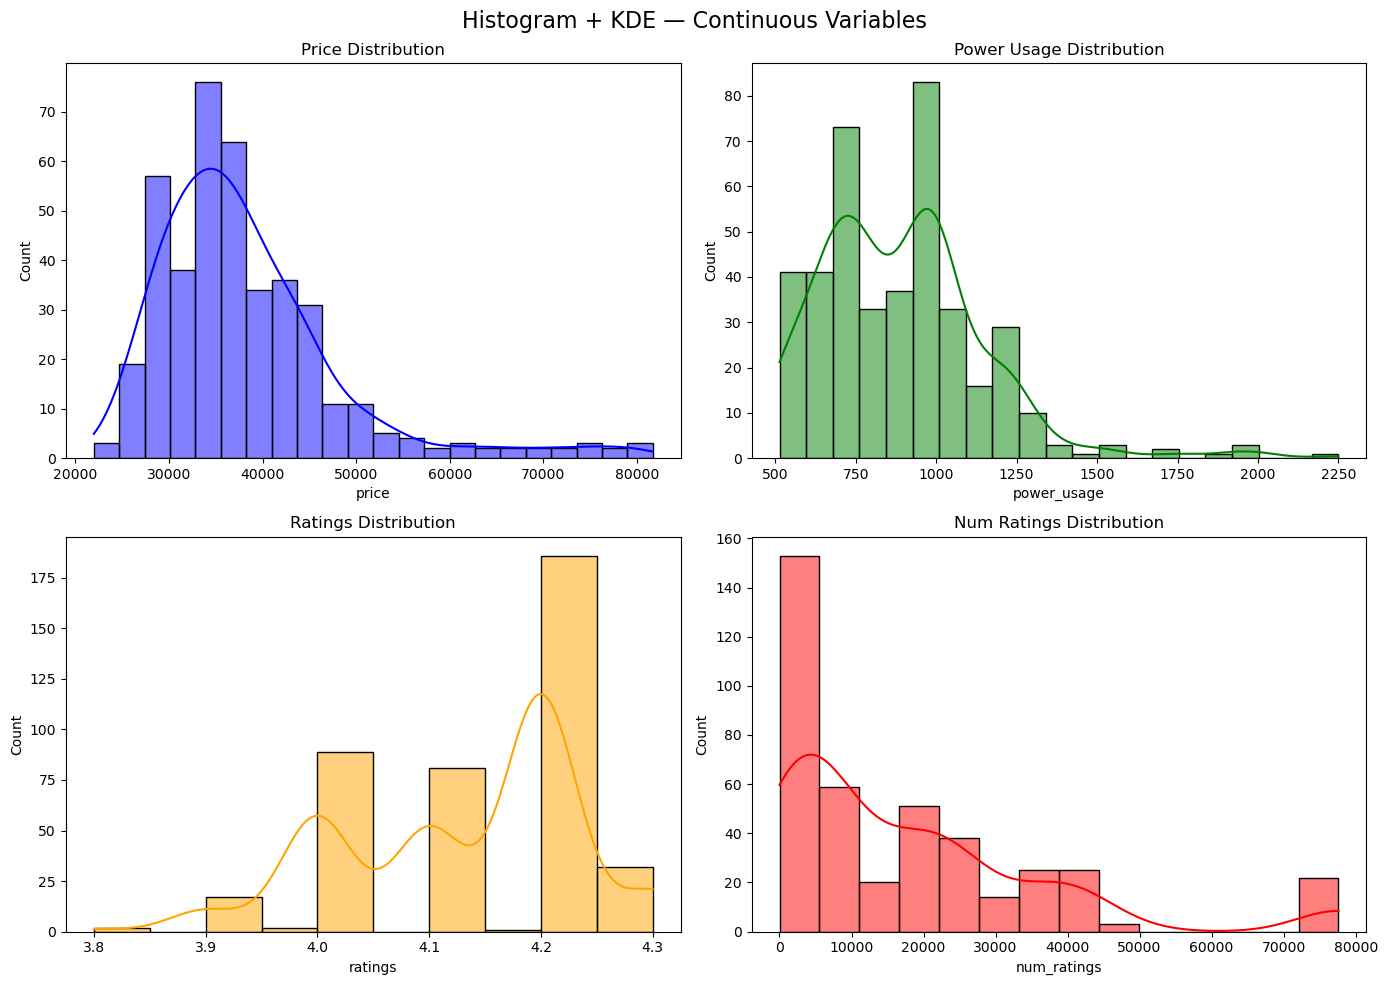

In [251]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['price'], kde=True, ax=axes[0,0], color='blue')
axes[0,0].set_title('Price Distribution')

sns.histplot(df['power_usage'], kde=True, ax=axes[0,1], color='green')
axes[0,1].set_title('Power Usage Distribution')

sns.histplot(df['ratings'], kde=True, ax=axes[1,0], color='orange')
axes[1,0].set_title('Ratings Distribution')

sns.histplot(df['num_ratings'], kde=True, ax=axes[1,1], color='red')
axes[1,1].set_title('Num Ratings Distribution')

plt.suptitle('Histogram + KDE — Continuous Variables', fontsize=16)
plt.tight_layout()
plt.show()

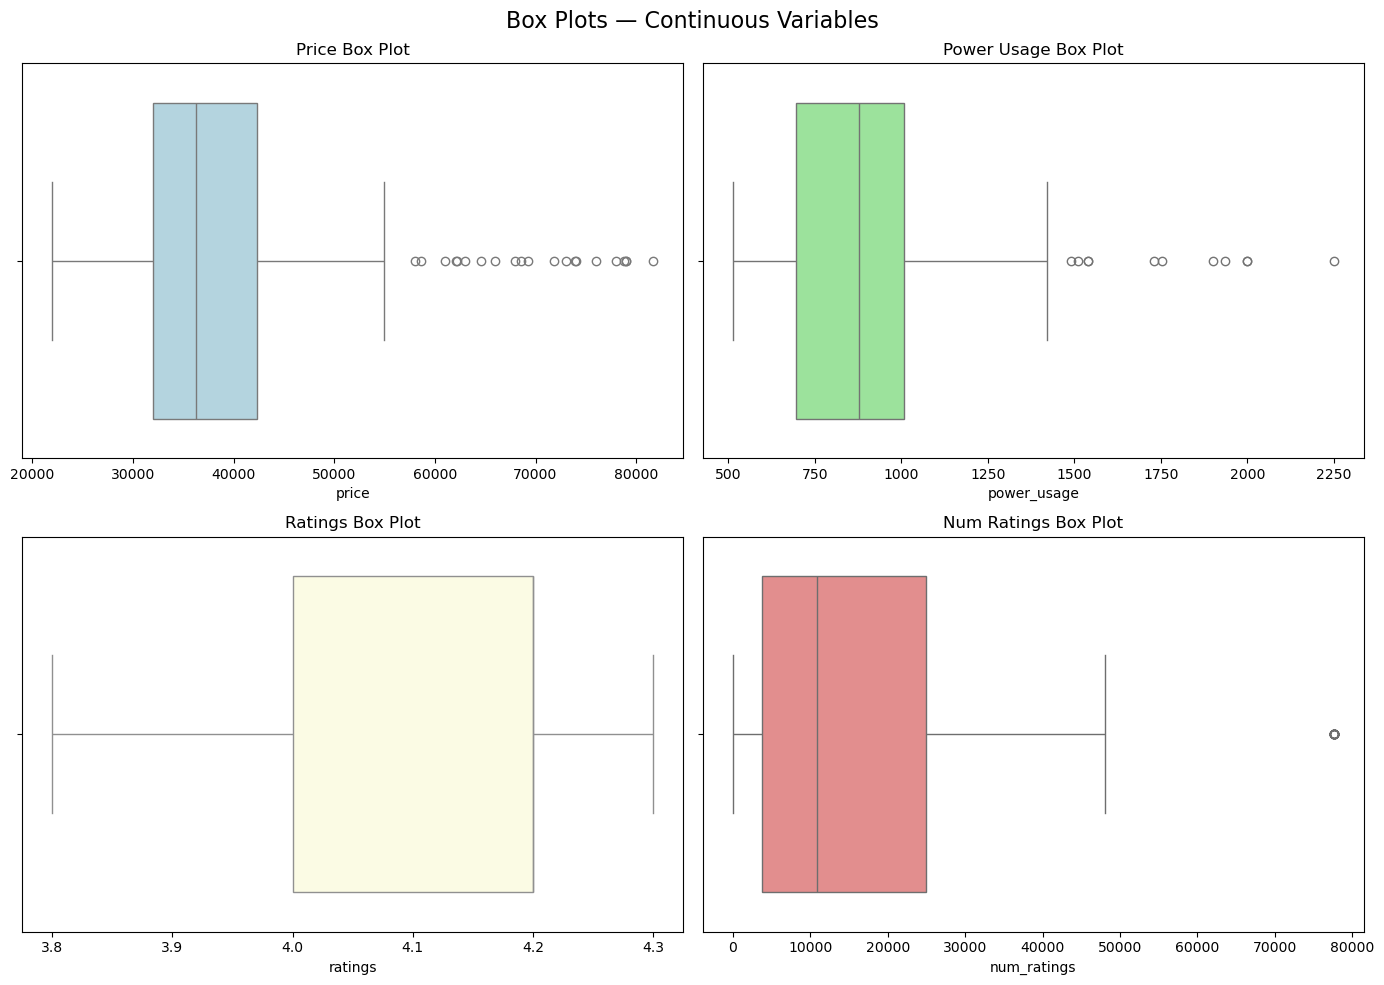

In [252]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(x=df['price'], ax=axes[0,0], color='lightblue')
axes[0,0].set_title('Price Box Plot')

sns.boxplot(x=df['power_usage'], ax=axes[0,1], color='lightgreen')
axes[0,1].set_title('Power Usage Box Plot')

sns.boxplot(x=df['ratings'], ax=axes[1,0], color='lightyellow')
axes[1,0].set_title('Ratings Box Plot')

sns.boxplot(x=df['num_ratings'], ax=axes[1,1], color='lightcoral')
axes[1,1].set_title('Num Ratings Box Plot')

plt.suptitle('Box Plots — Continuous Variables', fontsize=16)
plt.tight_layout()
plt.show()

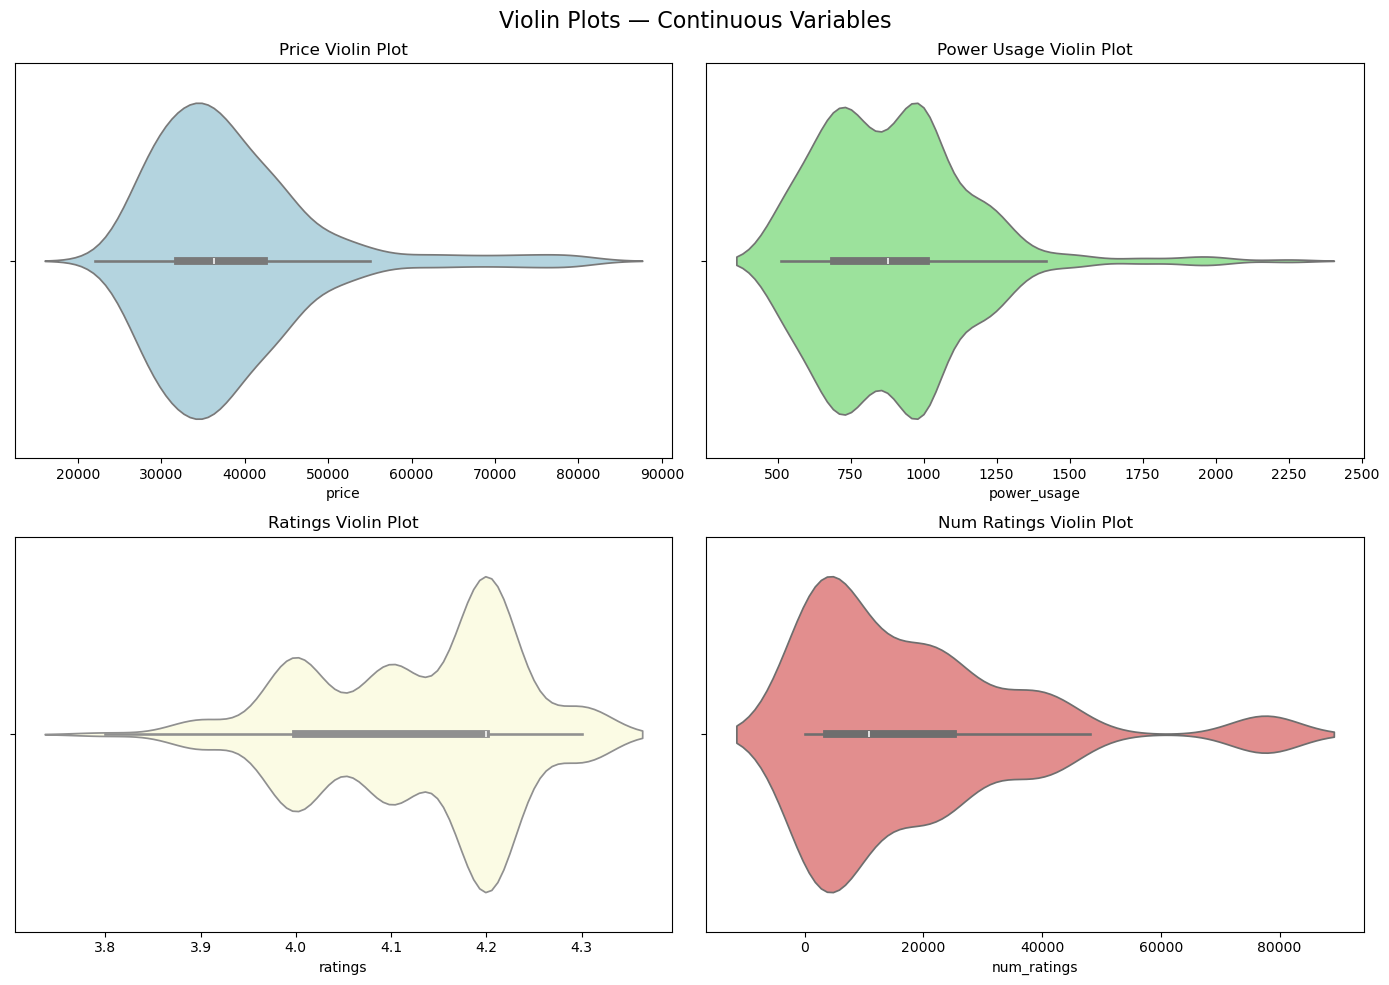

In [253]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.violinplot(x=df['price'], ax=axes[0,0], color='lightblue')
axes[0,0].set_title('Price Violin Plot')

sns.violinplot(x=df['power_usage'], ax=axes[0,1], color='lightgreen')
axes[0,1].set_title('Power Usage Violin Plot')

sns.violinplot(x=df['ratings'], ax=axes[1,0], color='lightyellow')
axes[1,0].set_title('Ratings Violin Plot')

sns.violinplot(x=df['num_ratings'], ax=axes[1,1], color='lightcoral')
axes[1,1].set_title('Num Ratings Violin Plot')

plt.suptitle('Violin Plots — Continuous Variables', fontsize=16)
plt.tight_layout()
plt.show()

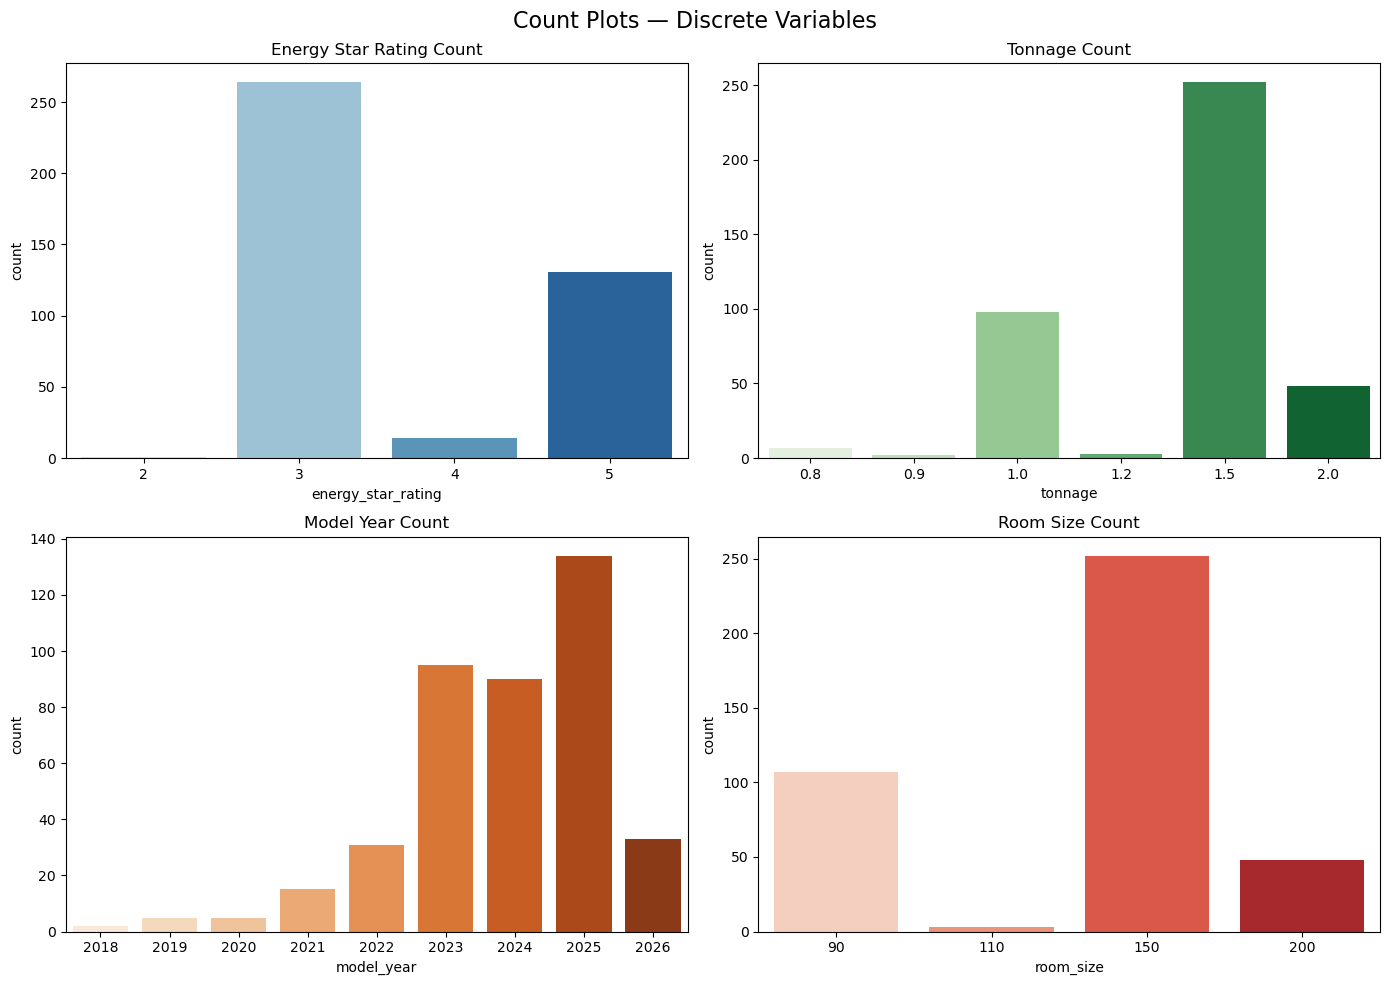

In [254]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(x=df['energy_star_rating'], ax=axes[0,0], palette='Blues')
axes[0,0].set_title('Energy Star Rating Count')

sns.countplot(x=df['tonnage'], ax=axes[0,1], palette='Greens')
axes[0,1].set_title('Tonnage Count')

sns.countplot(x=df['model_year'], ax=axes[1,0], palette='Oranges')
axes[1,0].set_title('Model Year Count')

sns.countplot(x=df['room_size'], ax=axes[1,1], palette='Reds')
axes[1,1].set_title('Room Size Count')

plt.suptitle('Count Plots — Discrete Variables', fontsize=16)
plt.tight_layout()
plt.show()

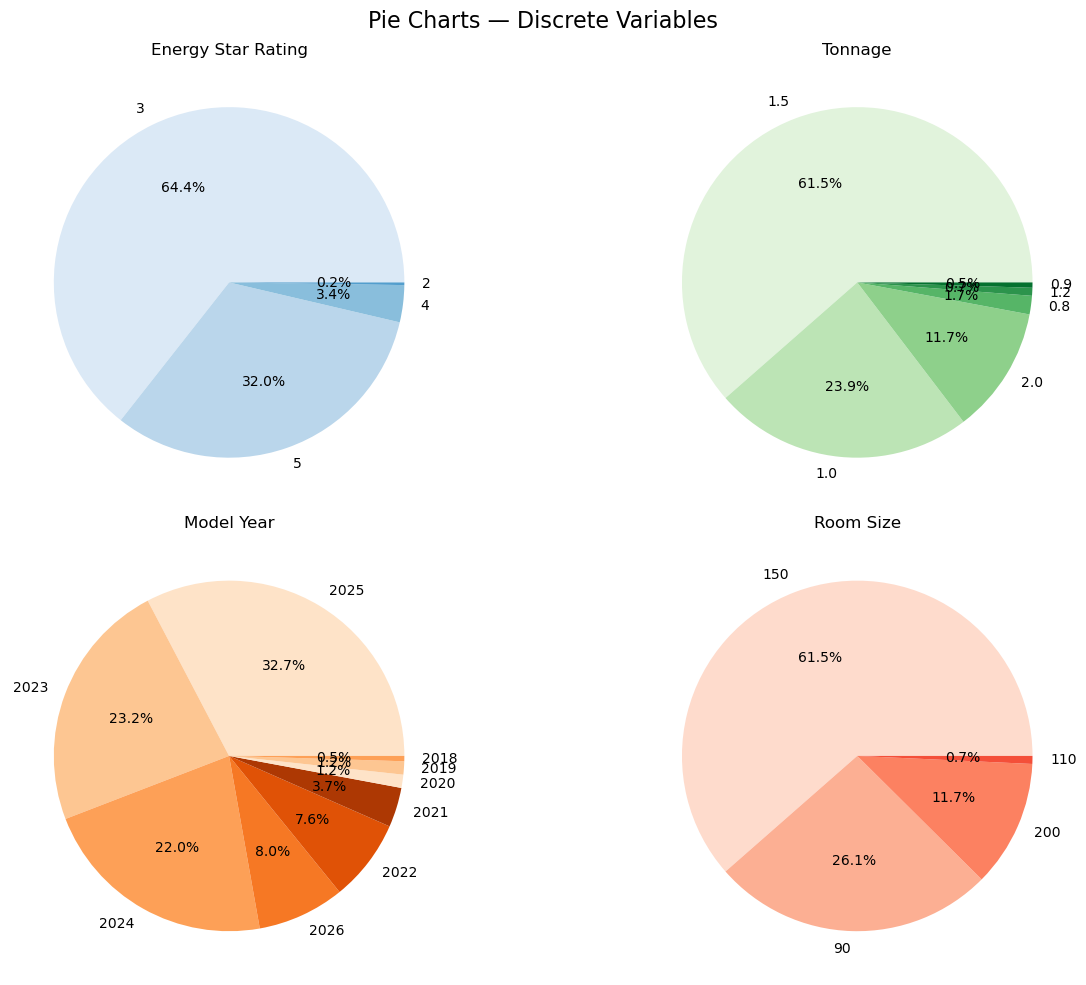

In [258]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df['energy_star_rating'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[0,0], colors=sns.color_palette('Blues'))
axes[0,0].set_title('Energy Star Rating')
axes[0,0].set_ylabel('')

df['tonnage'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[0,1], colors=sns.color_palette('Greens'))
axes[0,1].set_title('Tonnage')
axes[0,1].set_ylabel('')

df['model_year'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1,0], colors=sns.color_palette('Oranges'))
axes[1,0].set_title('Model Year')
axes[1,0].set_ylabel('')

df['room_size'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1,1], colors=sns.color_palette('Reds'))
axes[1,1].set_title('Room Size')
axes[1,1].set_ylabel('')

plt.suptitle('Pie Charts — Discrete Variables', fontsize=16)
plt.tight_layout()
plt.show()

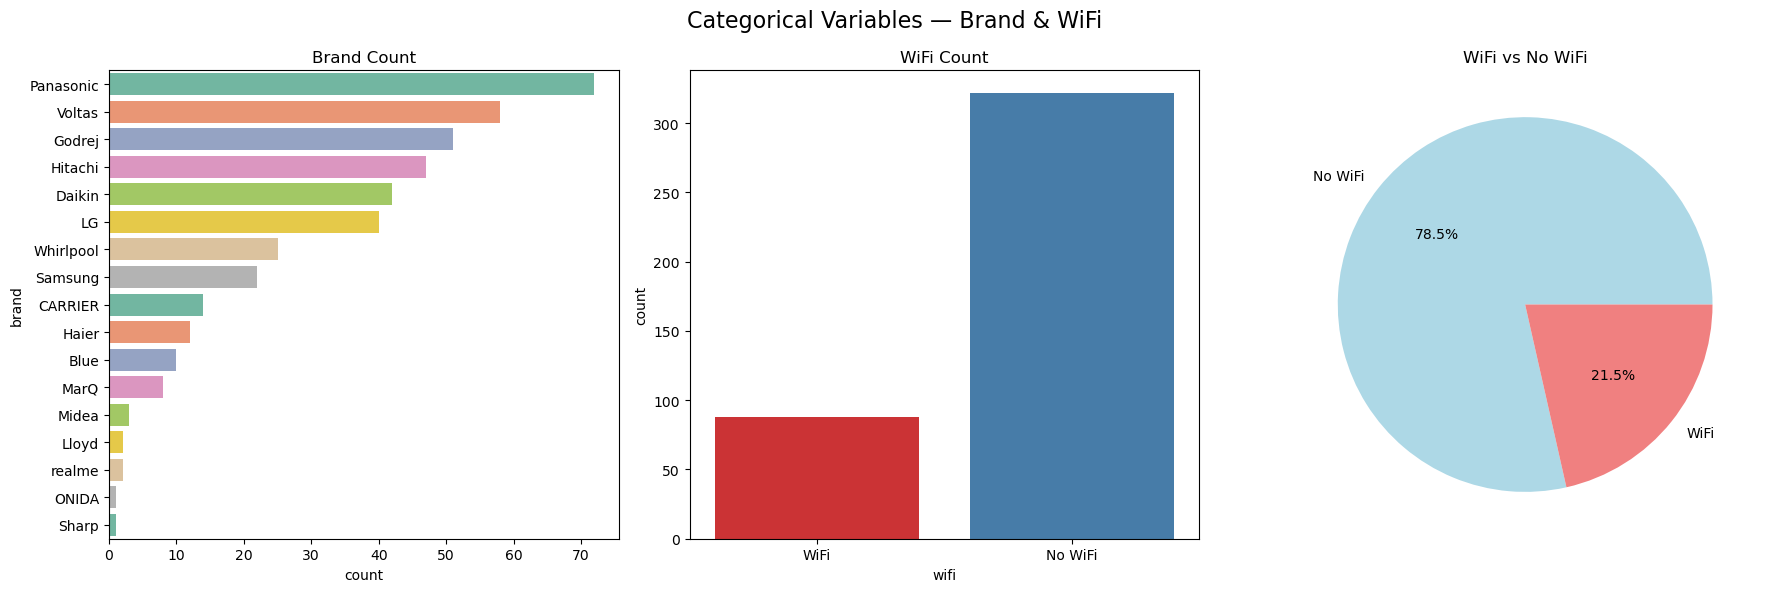

In [260]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Brand Count Plot
sns.countplot(y=df['brand'], ax=axes[0], palette='Set2', 
              order=df['brand'].value_counts().index)
axes[0].set_title('Brand Count')

# WiFi Count Plot
sns.countplot(x=df['wifi'], ax=axes[1], palette='Set1')
axes[1].set_title('WiFi Count')

# WiFi Pie Chart
df['wifi'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[2], 
                                    colors=['lightblue','lightcoral'])
axes[2].set_title('WiFi vs No WiFi')
axes[2].set_ylabel('')

plt.suptitle('Categorical Variables — Brand & WiFi', fontsize=16)
plt.tight_layout()
plt.show()

In [261]:
print(df.groupby('brand')['price'].mean().sort_values(ascending=False).round(2))



brand
Sharp        54990.00
Lloyd        49048.00
LG           48143.35
Samsung      41108.41
Hitachi      40569.64
realme       40244.50
Panasonic    39841.14
Daikin       37958.21
MarQ         37555.88
CARRIER      35944.29
Voltas       35530.52
Blue         34806.70
Godrej       33406.98
Haier        33178.83
Whirlpool    32043.88
Midea        27990.00
ONIDA        27990.00
Name: price, dtype: float64


In [265]:
# Bivariate analysis


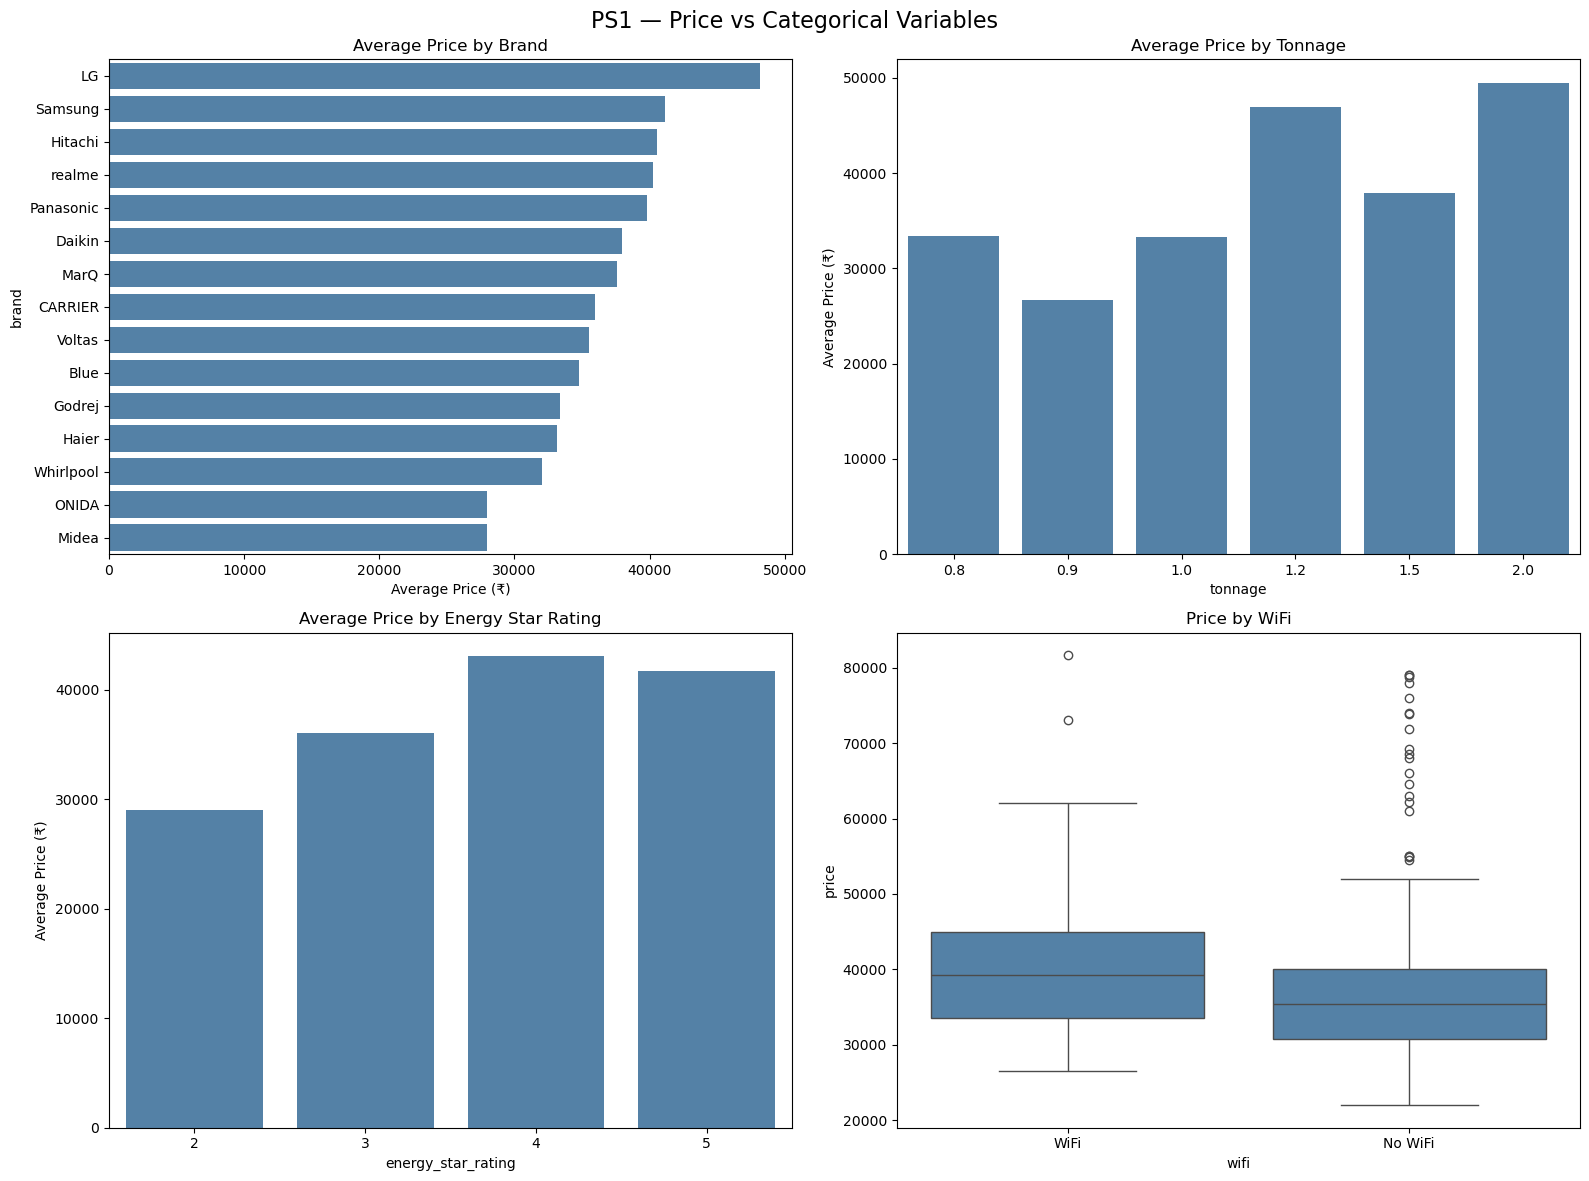

In [266]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Price by Brand
brand_price = df.groupby('brand')['price'].mean().sort_values(ascending=False)
sns.barplot(x=brand_price.values, y=brand_price.index, color='steelblue', ax=axes[0,0])
axes[0,0].set_title('Average Price by Brand')
axes[0,0].set_xlabel('Average Price (₹)')

# Price by Tonnage
tonnage_price = df.groupby('tonnage')['price'].mean().sort_values(ascending=False)
sns.barplot(x=tonnage_price.index, y=tonnage_price.values, color='steelblue', ax=axes[0,1])
axes[0,1].set_title('Average Price by Tonnage')
axes[0,1].set_ylabel('Average Price (₹)')

# Price by Energy Star Rating
star_price = df.groupby('energy_star_rating')['price'].mean().sort_values(ascending=False)
sns.barplot(x=star_price.index, y=star_price.values, color='steelblue', ax=axes[1,0])
axes[1,0].set_title('Average Price by Energy Star Rating')
axes[1,0].set_ylabel('Average Price (₹)')

# Price by WiFi
sns.boxplot(x='wifi', y='price', data=df, color='steelblue', ax=axes[1,1])
axes[1,1].set_title('Price by WiFi')

plt.suptitle('PS1 — Price vs Categorical Variables', fontsize=16)
plt.tight_layout()
plt.show()

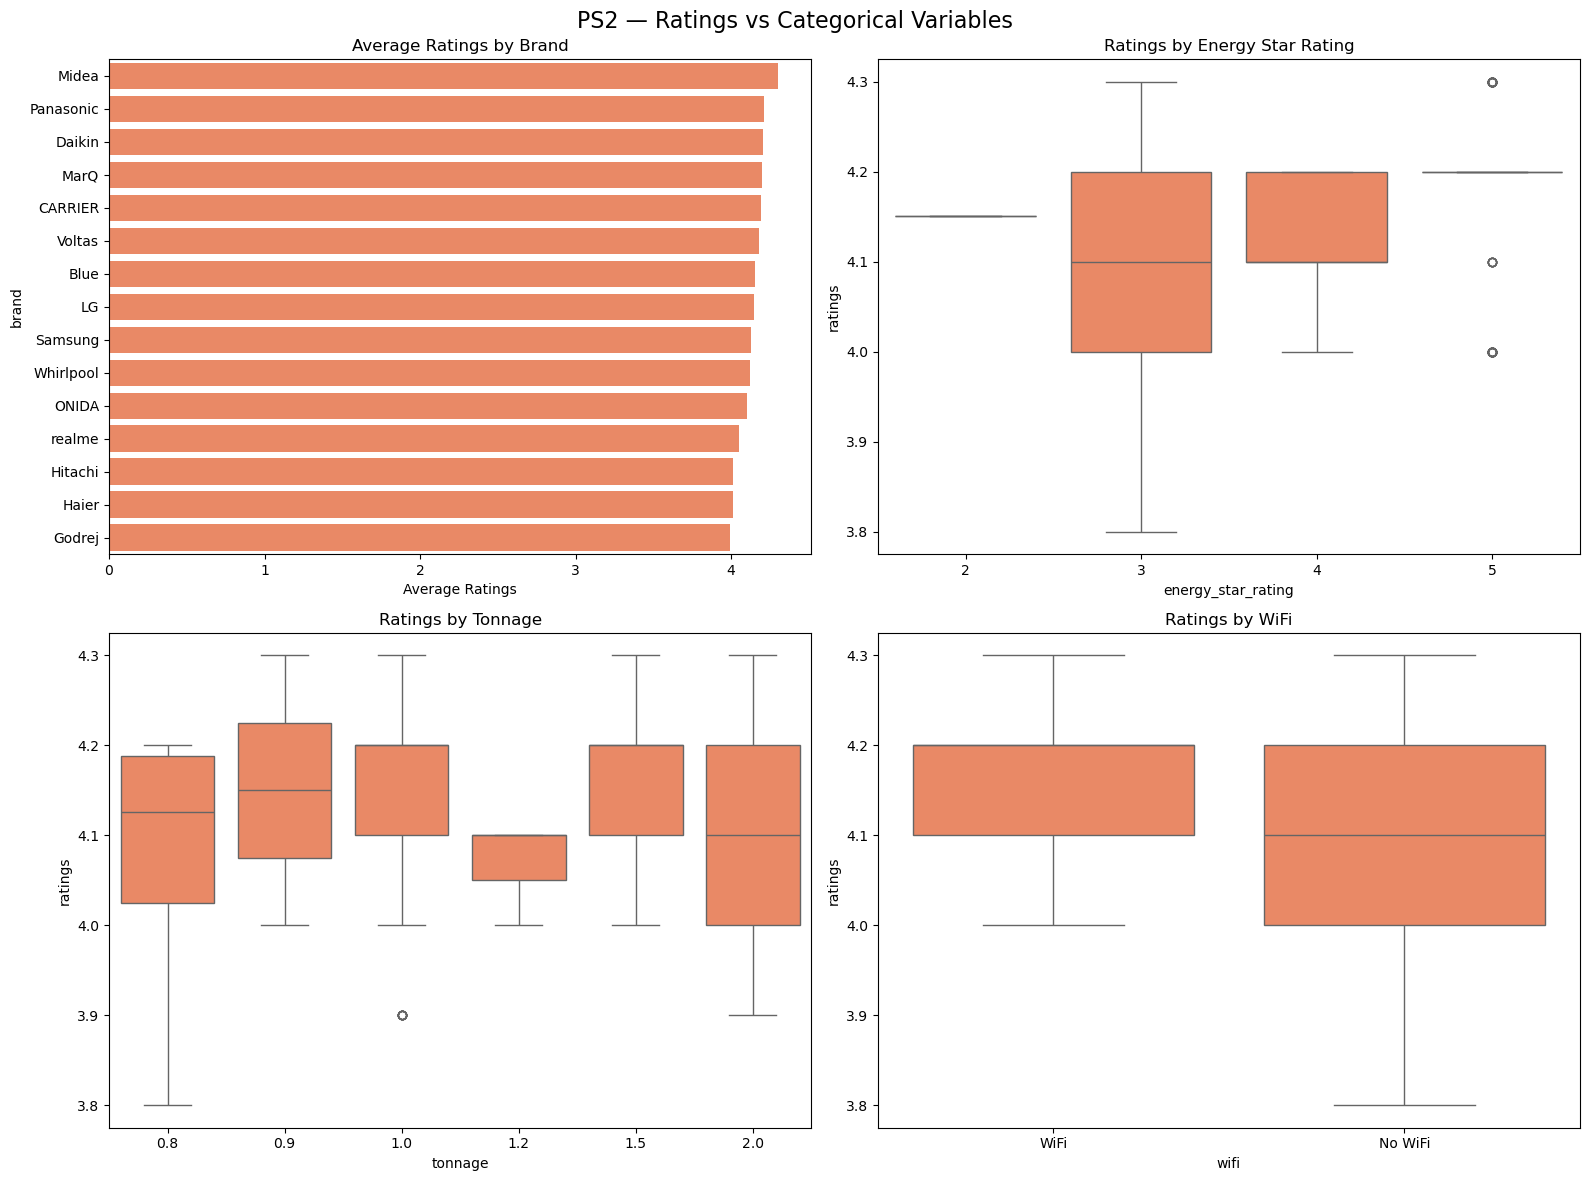

In [267]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Ratings by Brand
brand_ratings = df.groupby('brand')['ratings'].mean().sort_values(ascending=False)
sns.barplot(x=brand_ratings.values, y=brand_ratings.index, color='coral', ax=axes[0,0])
axes[0,0].set_title('Average Ratings by Brand')
axes[0,0].set_xlabel('Average Ratings')

# Ratings by Energy Star Rating
sns.boxplot(x='energy_star_rating', y='ratings', data=df, color='coral', ax=axes[0,1])
axes[0,1].set_title('Ratings by Energy Star Rating')

# Ratings by Tonnage
sns.boxplot(x='tonnage', y='ratings', data=df, color='coral', ax=axes[1,0])
axes[1,0].set_title('Ratings by Tonnage')

# Ratings by WiFi
sns.boxplot(x='wifi', y='ratings', data=df, color='coral', ax=axes[1,1])
axes[1,1].set_title('Ratings by WiFi')

plt.suptitle('PS2 — Ratings vs Categorical Variables', fontsize=16)
plt.tight_layout()
plt.show()

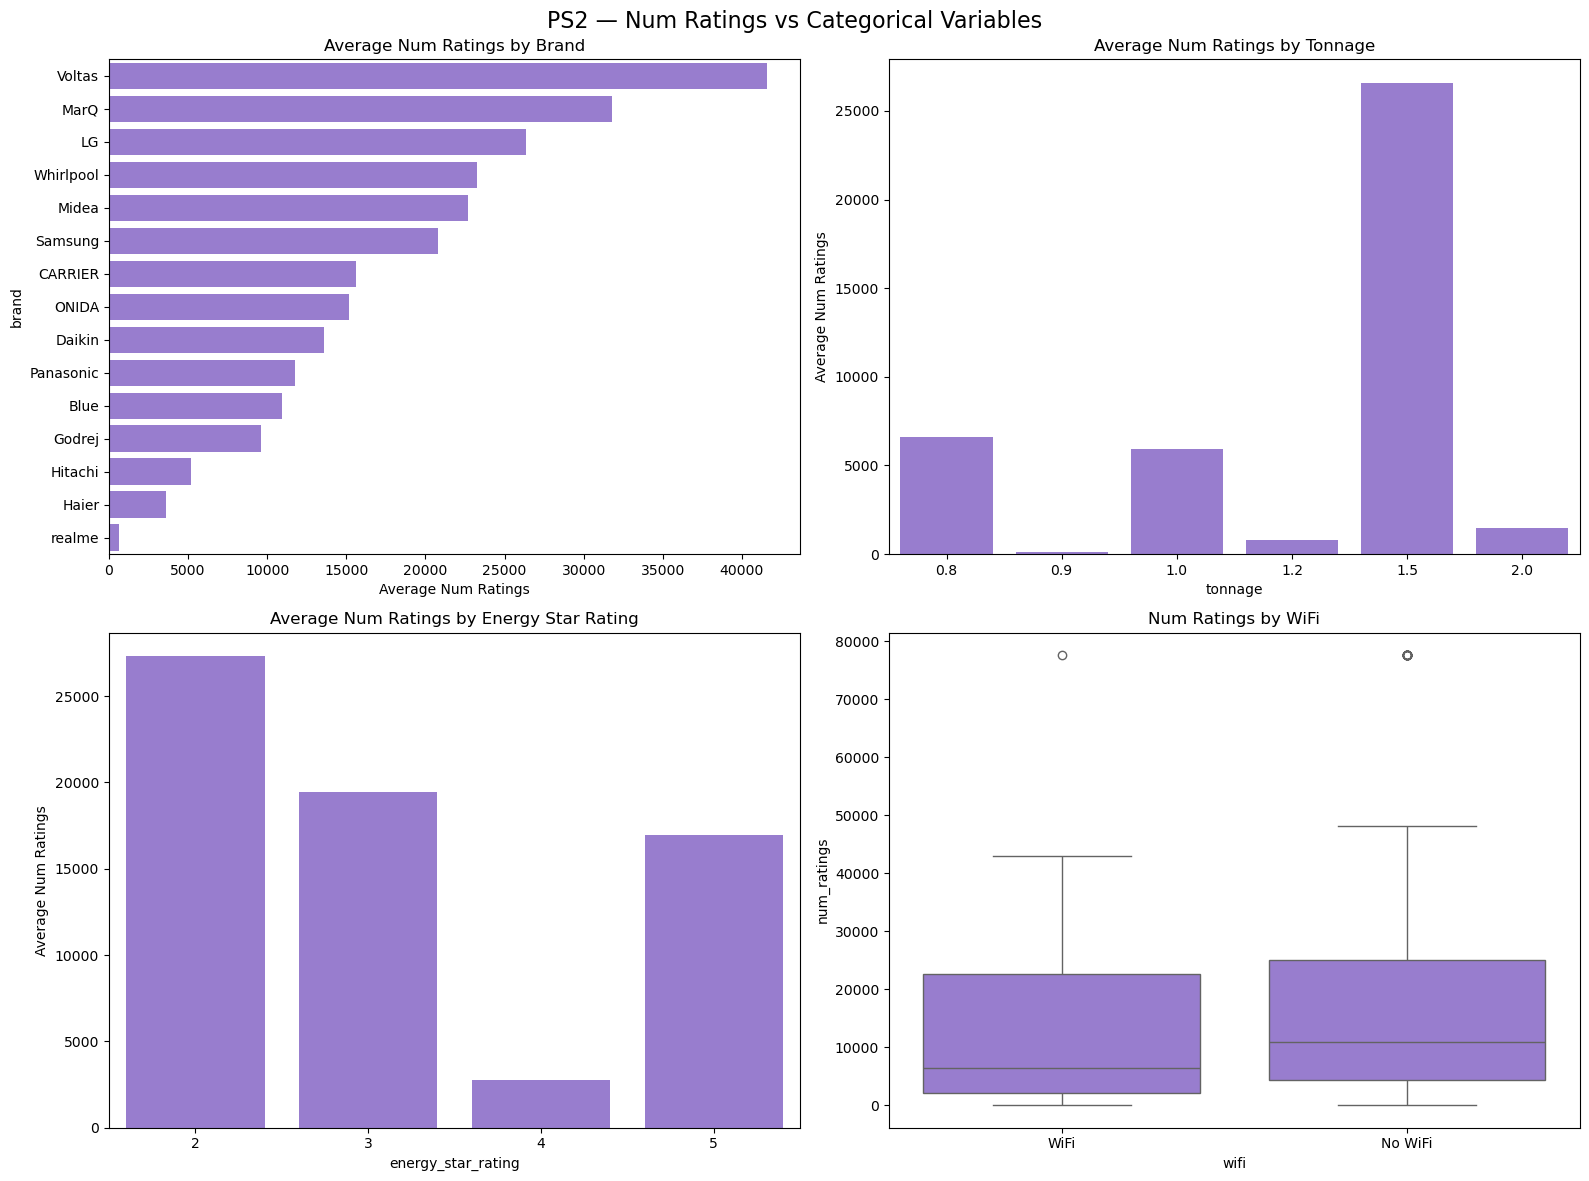

In [268]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Num Ratings by Brand
brand_numratings = df.groupby('brand')['num_ratings'].mean().sort_values(ascending=False)
sns.barplot(x=brand_numratings.values, y=brand_numratings.index, color='mediumpurple', ax=axes[0,0])
axes[0,0].set_title('Average Num Ratings by Brand')
axes[0,0].set_xlabel('Average Num Ratings')

# Num Ratings by Tonnage
tonnage_numratings = df.groupby('tonnage')['num_ratings'].mean().sort_values(ascending=False)
sns.barplot(x=tonnage_numratings.index, y=tonnage_numratings.values, color='mediumpurple', ax=axes[0,1])
axes[0,1].set_title('Average Num Ratings by Tonnage')
axes[0,1].set_ylabel('Average Num Ratings')

# Num Ratings by Energy Star Rating
star_numratings = df.groupby('energy_star_rating')['num_ratings'].mean().sort_values(ascending=False)
sns.barplot(x=star_numratings.index, y=star_numratings.values, color='mediumpurple', ax=axes[1,0])
axes[1,0].set_title('Average Num Ratings by Energy Star Rating')
axes[1,0].set_ylabel('Average Num Ratings')

# Num Ratings by WiFi
sns.boxplot(x='wifi', y='num_ratings', data=df, color='mediumpurple', ax=axes[1,1])
axes[1,1].set_title('Num Ratings by WiFi')

plt.suptitle('PS2 — Num Ratings vs Categorical Variables', fontsize=16)
plt.tight_layout()
plt.show()

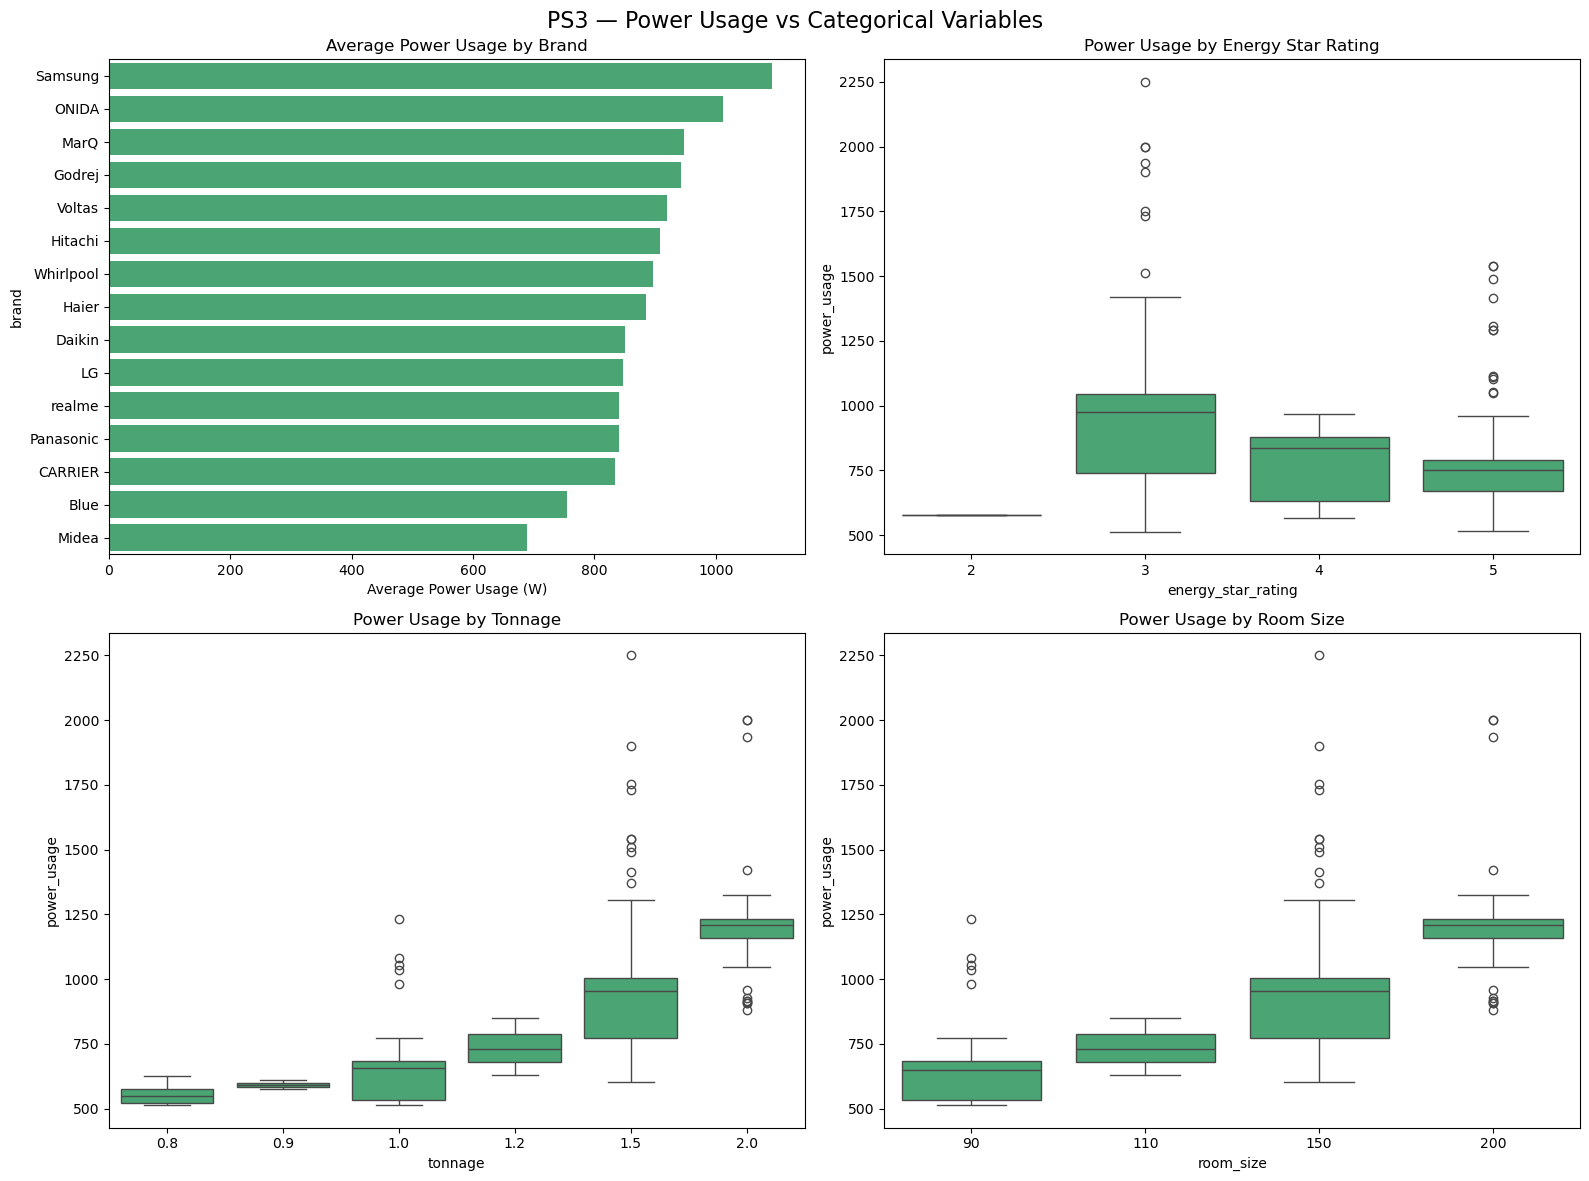

In [269]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Power Usage by Brand
brand_power = df.groupby('brand')['power_usage'].mean().sort_values(ascending=False)
sns.barplot(x=brand_power.values, y=brand_power.index, color='mediumseagreen', ax=axes[0,0])
axes[0,0].set_title('Average Power Usage by Brand')
axes[0,0].set_xlabel('Average Power Usage (W)')

# Power Usage by Energy Star Rating
sns.boxplot(x='energy_star_rating', y='power_usage', data=df, color='mediumseagreen', ax=axes[0,1])
axes[0,1].set_title('Power Usage by Energy Star Rating')

# Power Usage by Tonnage
sns.boxplot(x='tonnage', y='power_usage', data=df, color='mediumseagreen', ax=axes[1,0])
axes[1,0].set_title('Power Usage by Tonnage')

# Power Usage by Room Size
sns.boxplot(x='room_size', y='power_usage', data=df, color='mediumseagreen', ax=axes[1,1])
axes[1,1].set_title('Power Usage by Room Size')

plt.suptitle('PS3 — Power Usage vs Categorical Variables', fontsize=16)
plt.tight_layout()
plt.show()

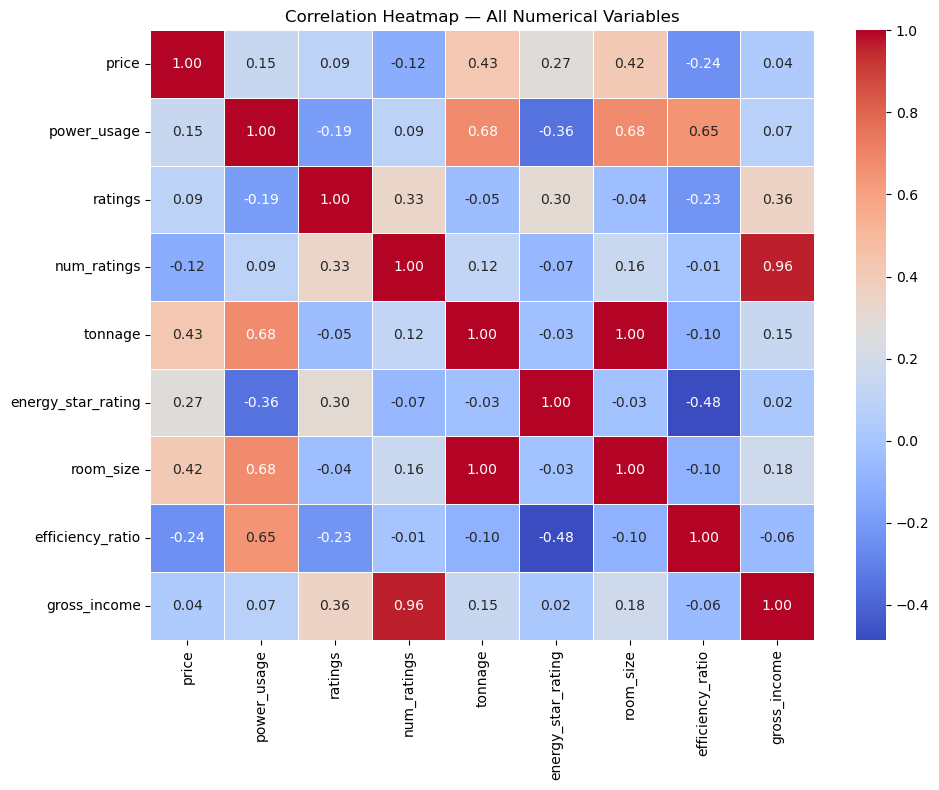

In [270]:
plt.figure(figsize=(10, 8))
corr = df[['price', 'power_usage', 'ratings', 'num_ratings', 
           'tonnage', 'energy_star_rating', 'room_size', 
           'efficiency_ratio', 'gross_income']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — All Numerical Variables')
plt.tight_layout()
plt.show()

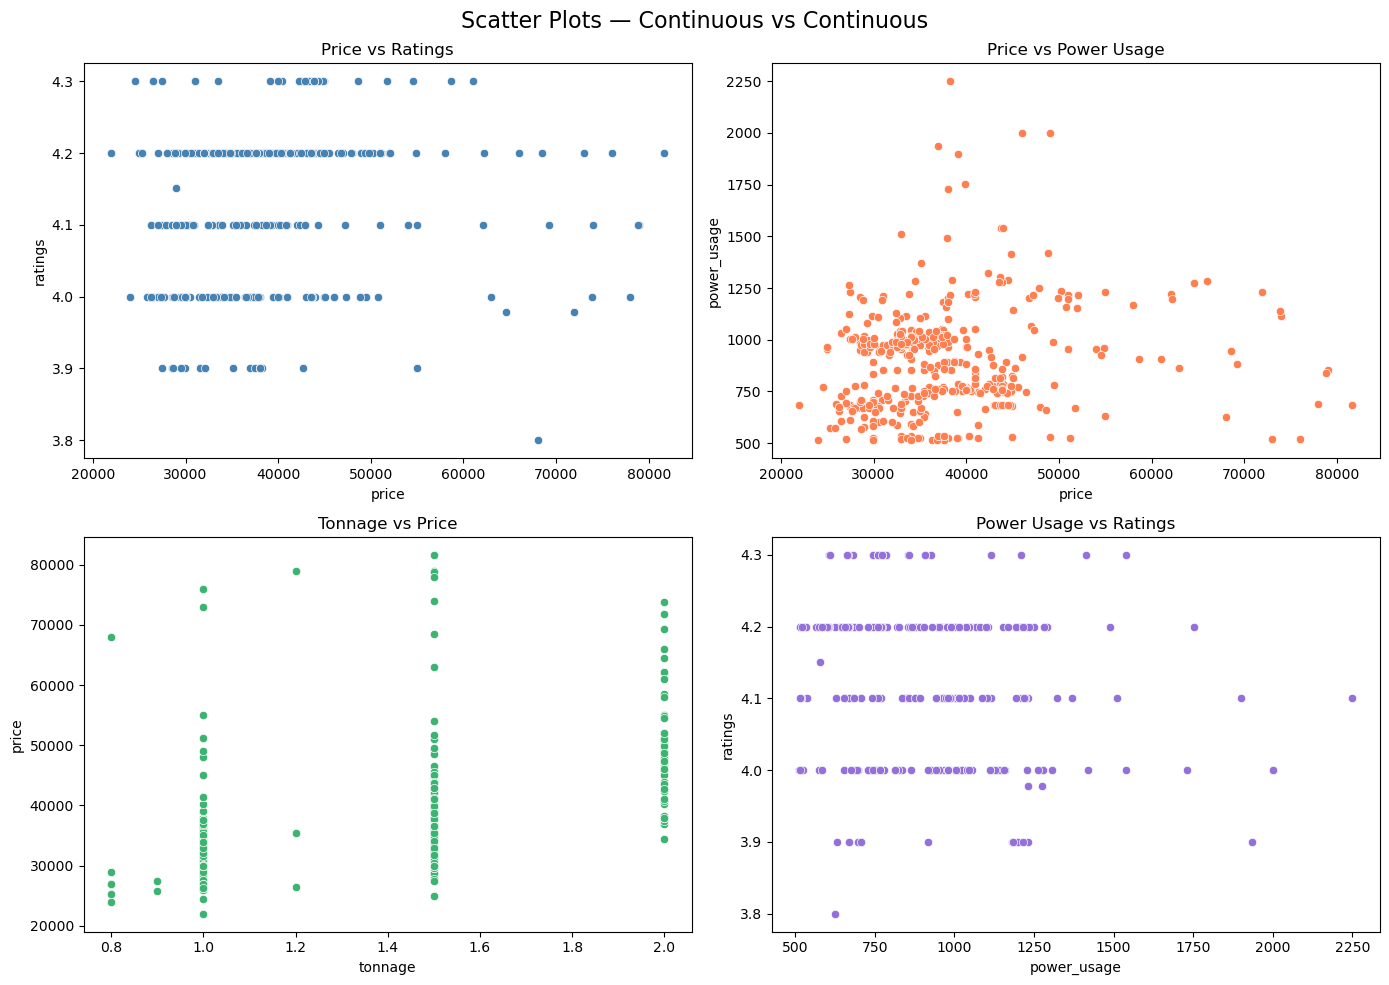

In [271]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(x='price', y='ratings', data=df, color='steelblue', ax=axes[0,0])
axes[0,0].set_title('Price vs Ratings')

sns.scatterplot(x='price', y='power_usage', data=df, color='coral', ax=axes[0,1])
axes[0,1].set_title('Price vs Power Usage')

sns.scatterplot(x='tonnage', y='price', data=df, color='mediumseagreen', ax=axes[1,0])
axes[1,0].set_title('Tonnage vs Price')

sns.scatterplot(x='power_usage', y='ratings', data=df, color='mediumpurple', ax=axes[1,1])
axes[1,1].set_title('Power Usage vs Ratings')

plt.suptitle('Scatter Plots — Continuous vs Continuous', fontsize=16)
plt.tight_layout()
plt.show()

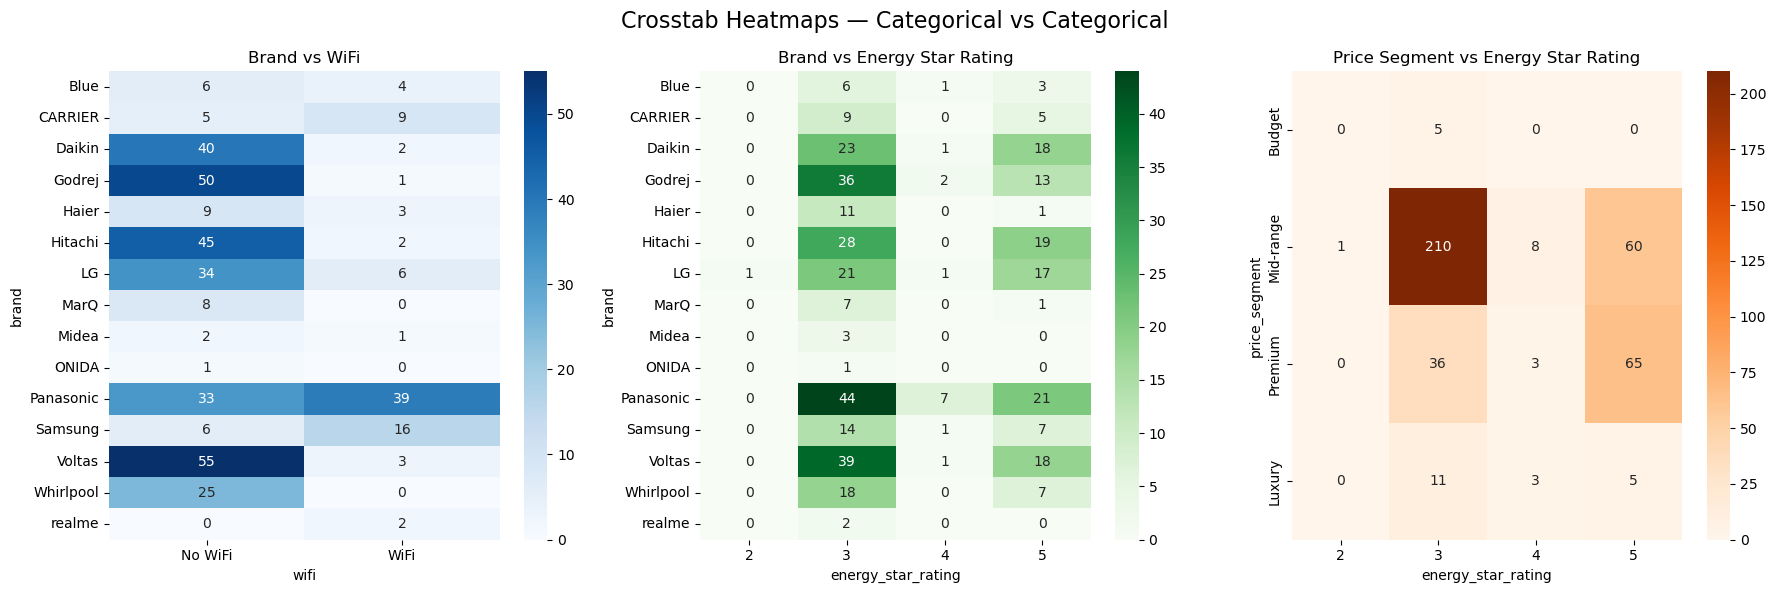

In [272]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Brand vs WiFi
ct1 = pd.crosstab(df['brand'], df['wifi'])
sns.heatmap(ct1, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Brand vs WiFi')

# Brand vs Energy Star Rating
ct2 = pd.crosstab(df['brand'], df['energy_star_rating'])
sns.heatmap(ct2, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Brand vs Energy Star Rating')

# Price Segment vs Energy Star Rating
ct3 = pd.crosstab(df['price_segment'], df['energy_star_rating'])
sns.heatmap(ct3, annot=True, fmt='d', cmap='Oranges', ax=axes[2])
axes[2].set_title('Price Segment vs Energy Star Rating')

plt.suptitle('Crosstab Heatmaps — Categorical vs Categorical', fontsize=16)
plt.tight_layout()
plt.show()

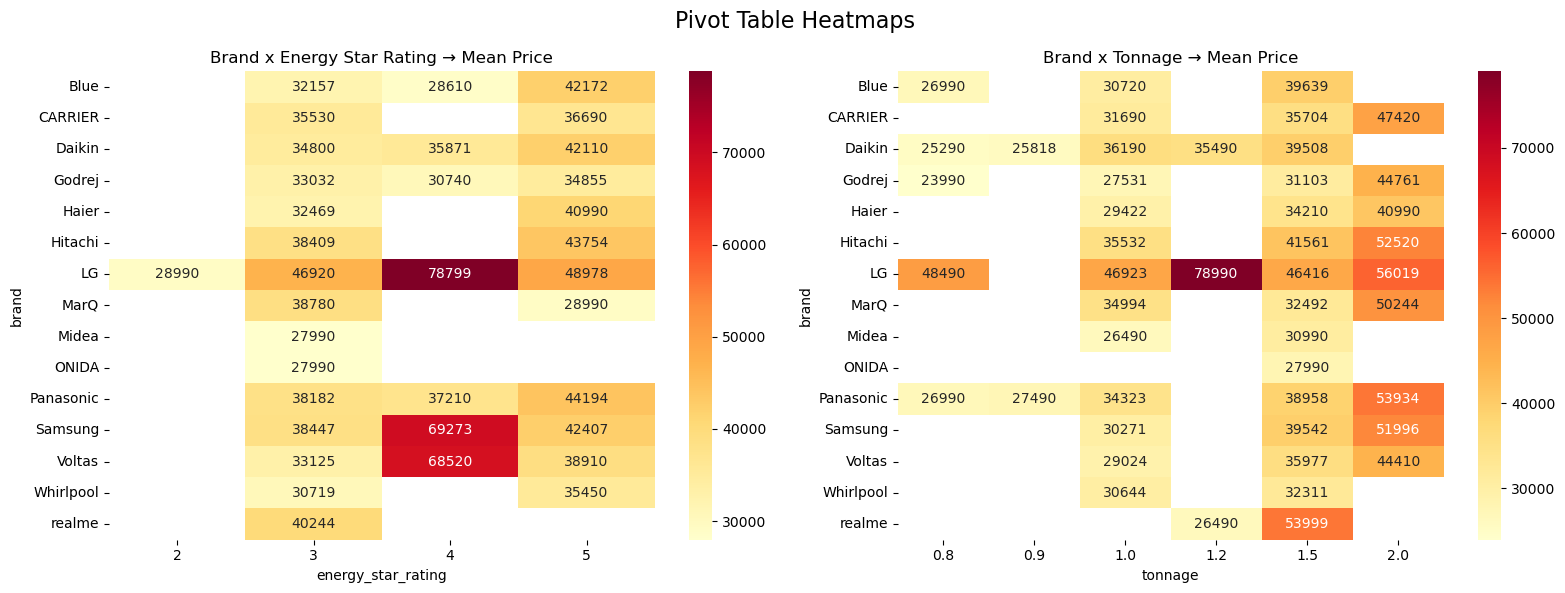

In [273]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Brand x Energy Star → Mean Price
pivot1 = pd.pivot_table(df, values='price', index='brand', 
                         columns='energy_star_rating', aggfunc='mean')
sns.heatmap(pivot1, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[0])
axes[0].set_title('Brand x Energy Star Rating → Mean Price')

# Brand x Tonnage → Mean Price
pivot2 = pd.pivot_table(df, values='price', index='brand', 
                         columns='tonnage', aggfunc='mean')
sns.heatmap(pivot2, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Brand x Tonnage → Mean Price')

plt.suptitle('Pivot Table Heatmaps', fontsize=16)
plt.tight_layout()
plt.show()

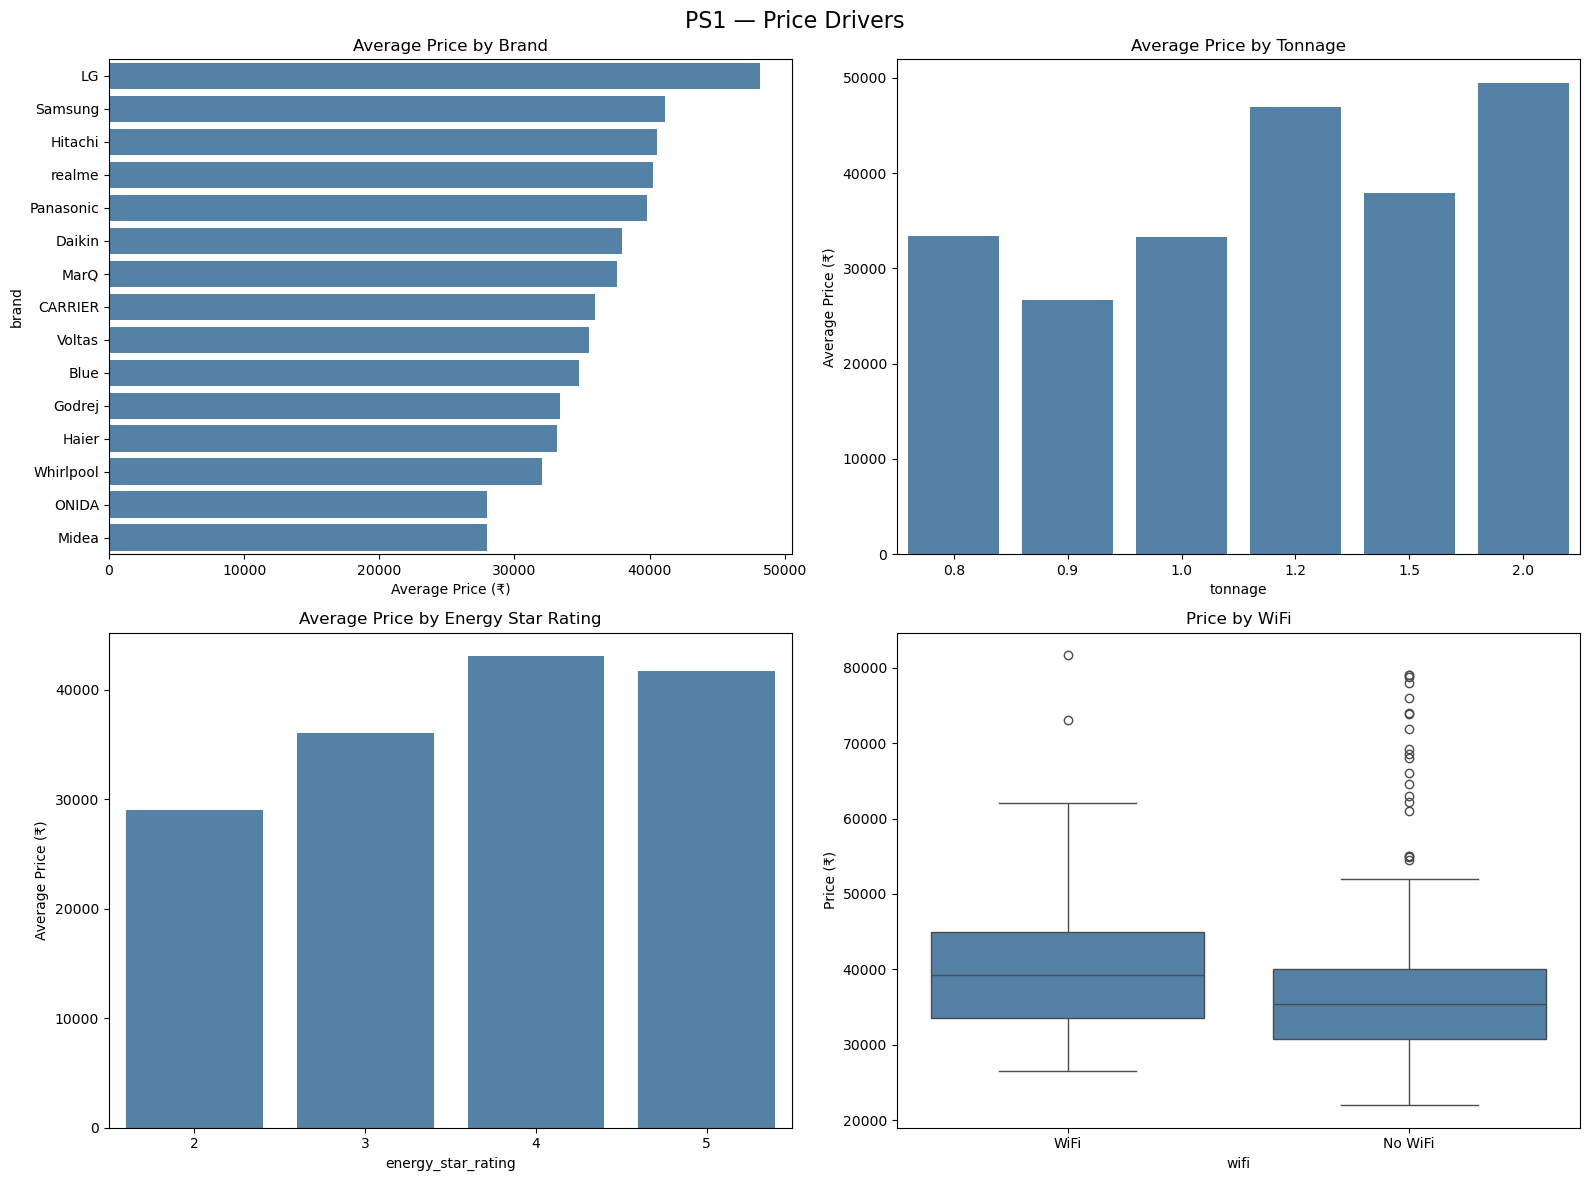

In [274]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Price by Brand
brand_price = df.groupby('brand')['price'].mean().sort_values(ascending=False)
sns.barplot(x=brand_price.values, y=brand_price.index, color='steelblue', ax=axes[0,0])
axes[0,0].set_title('Average Price by Brand')
axes[0,0].set_xlabel('Average Price (₹)')

# Price by Tonnage
tonnage_price = df.groupby('tonnage')['price'].mean()
sns.barplot(x=tonnage_price.index, y=tonnage_price.values, color='steelblue', ax=axes[0,1])
axes[0,1].set_title('Average Price by Tonnage')
axes[0,1].set_ylabel('Average Price (₹)')

# Price by Energy Star Rating
star_price = df.groupby('energy_star_rating')['price'].mean()
sns.barplot(x=star_price.index, y=star_price.values, color='steelblue', ax=axes[1,0])
axes[1,0].set_title('Average Price by Energy Star Rating')
axes[1,0].set_ylabel('Average Price (₹)')

# Price by WiFi
sns.boxplot(x='wifi', y='price', data=df, color='steelblue', ax=axes[1,1])
axes[1,1].set_title('Price by WiFi')
axes[1,1].set_ylabel('Price (₹)')

plt.suptitle('PS1 — Price Drivers', fontsize=16)
plt.tight_layout()
plt.show()

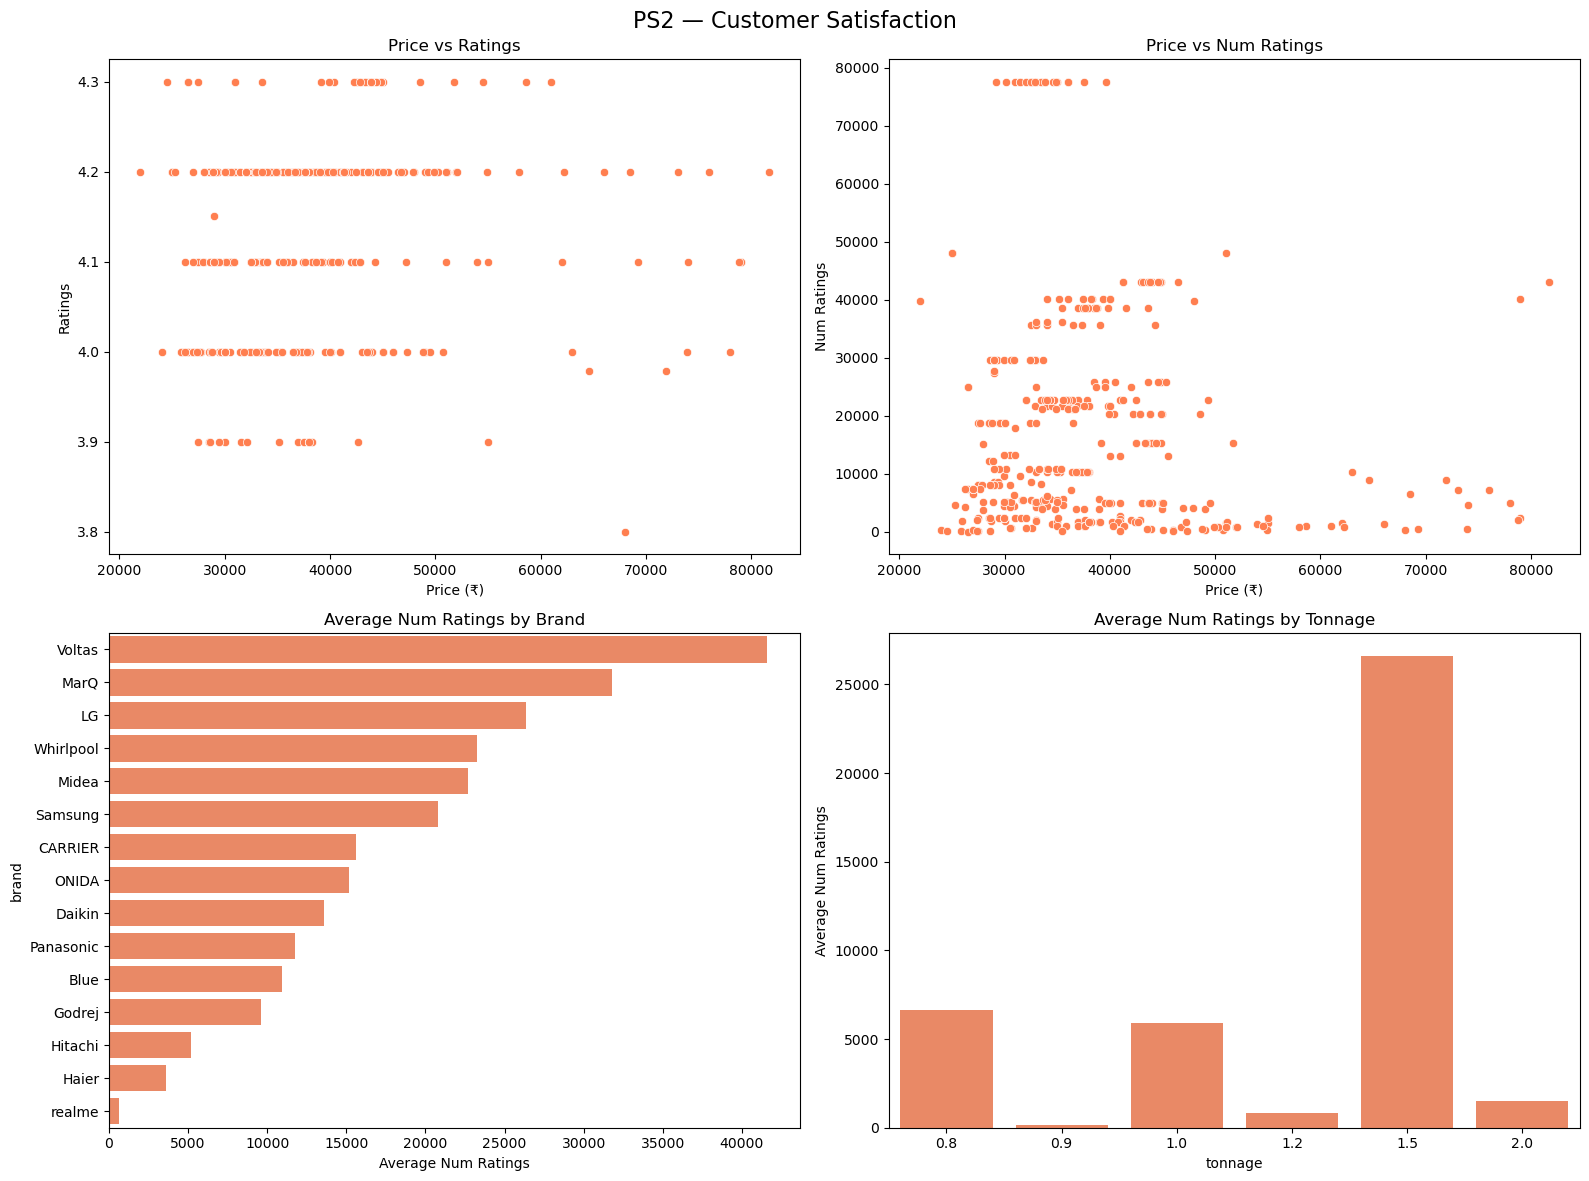

In [278]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Price vs Ratings Scatter
sns.scatterplot(x='price', y='ratings', data=df, color='coral', ax=axes[0,0])
axes[0,0].set_title('Price vs Ratings')
axes[0,0].set_xlabel('Price (₹)')
axes[0,0].set_ylabel('Ratings')

# Price vs Num Ratings Scatter
sns.scatterplot(x='price', y='num_ratings', data=df, color='coral', ax=axes[0,1])
axes[0,1].set_title('Price vs Num Ratings')
axes[0,1].set_xlabel('Price (₹)')
axes[0,1].set_ylabel('Num Ratings')

# Num Ratings by Brand
brand_numratings = df.groupby('brand')['num_ratings'].mean().sort_values(ascending=False)
sns.barplot(x=brand_numratings.values, y=brand_numratings.index, color='coral', ax=axes[1,0])
axes[1,0].set_title('Average Num Ratings by Brand')
axes[1,0].set_xlabel('Average Num Ratings')

# Num Ratings by Tonnage
tonnage_numratings = df.groupby('tonnage')['num_ratings'].mean()
sns.barplot(x=tonnage_numratings.index, y=tonnage_numratings.values, color='coral', ax=axes[1,1])
axes[1,1].set_title('Average Num Ratings by Tonnage')
axes[1,1].set_ylabel('Average Num Ratings')

plt.suptitle('PS2 — Customer Satisfaction', fontsize=16)
plt.tight_layout()
plt.show()

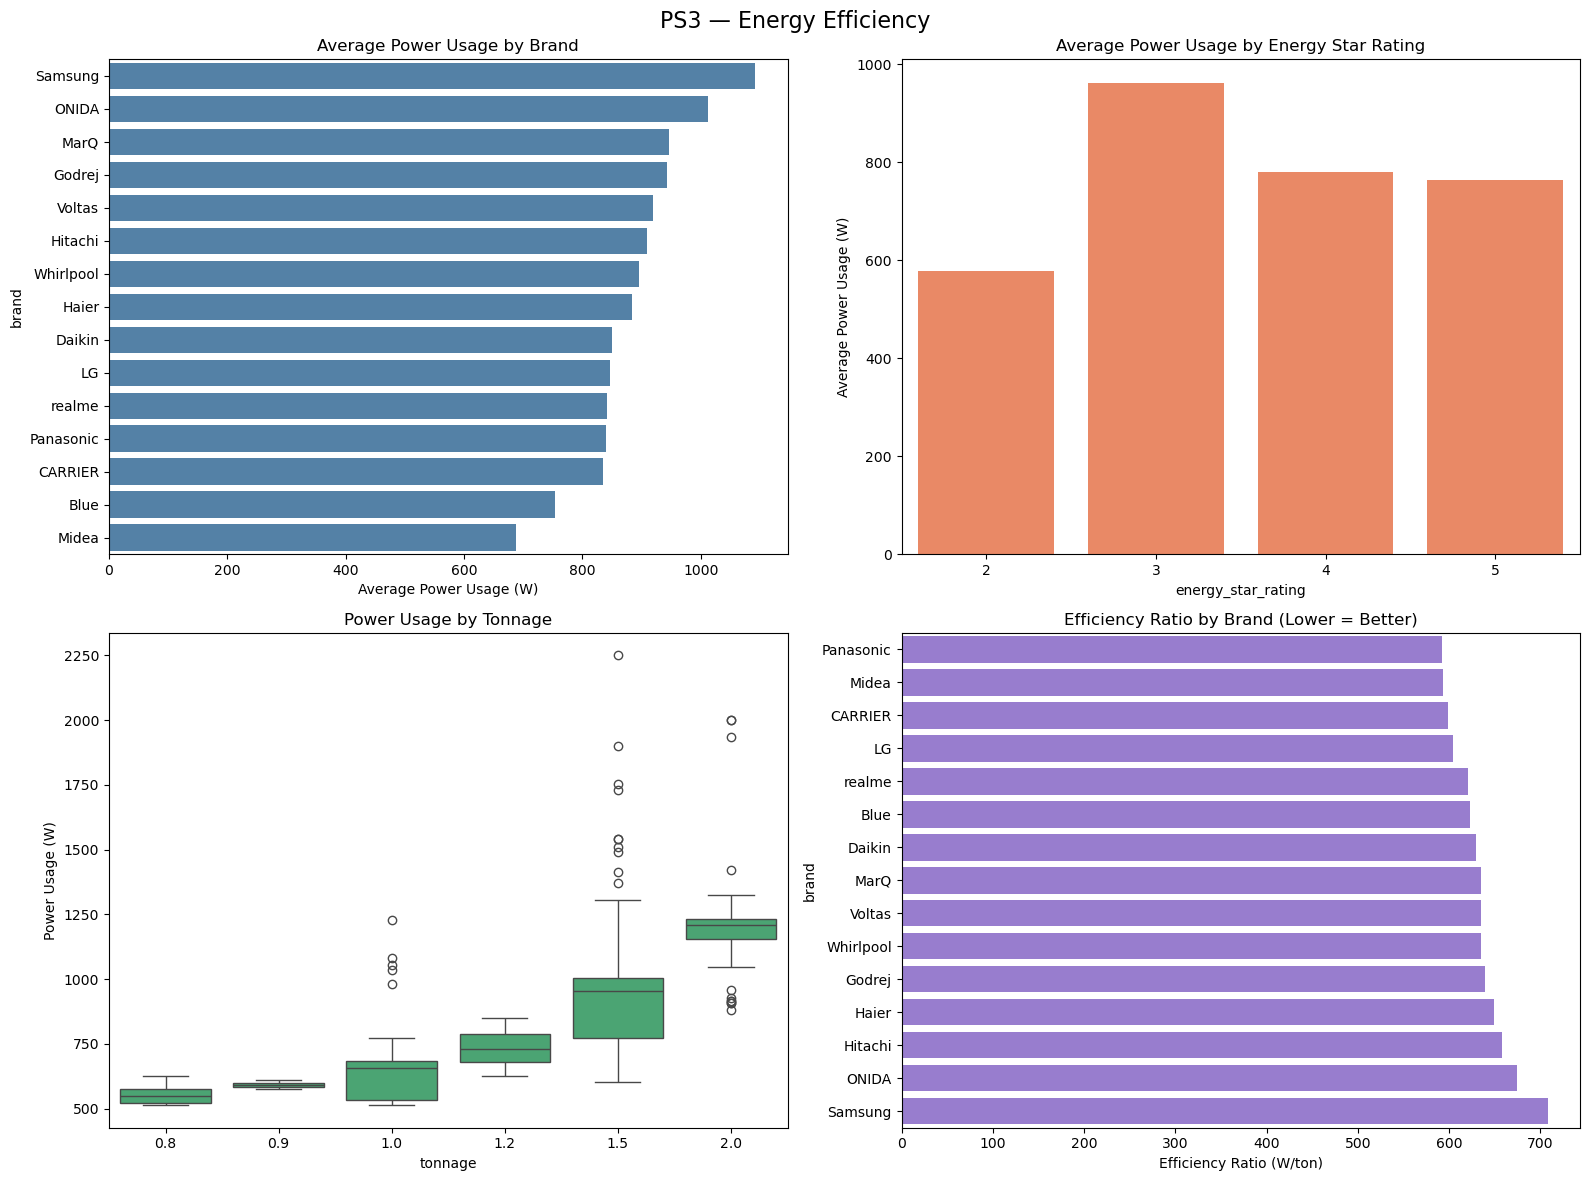

In [280]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Power Usage by Brand
brand_power = df.groupby('brand')['power_usage'].mean().sort_values(ascending=False)
sns.barplot(x=brand_power.values, y=brand_power.index, color='steelblue', ax=axes[0,0])
axes[0,0].set_title('Average Power Usage by Brand')
axes[0,0].set_xlabel('Average Power Usage (W)')

# Power Usage by Energy Star Rating
star_power = df.groupby('energy_star_rating')['power_usage'].mean()
sns.barplot(x=star_power.index, y=star_power.values, color='coral', ax=axes[0,1])
axes[0,1].set_title('Average Power Usage by Energy Star Rating')
axes[0,1].set_ylabel('Average Power Usage (W)')

# Power Usage by Tonnage
sns.boxplot(x='tonnage', y='power_usage', data=df, color='mediumseagreen', ax=axes[1,0])
axes[1,0].set_title('Power Usage by Tonnage')
axes[1,0].set_ylabel('Power Usage (W)')

# Efficiency Ratio by Brand
brand_efficiency = df.groupby('brand')['efficiency_ratio'].mean().sort_values()
sns.barplot(x=brand_efficiency.values, y=brand_efficiency.index, color='mediumpurple', ax=axes[1,1])
axes[1,1].set_title('Efficiency Ratio by Brand (Lower = Better)')
axes[1,1].set_xlabel('Efficiency Ratio (W/ton)')

plt.suptitle('PS3 — Energy Efficiency', fontsize=16)
plt.tight_layout()
plt.show()

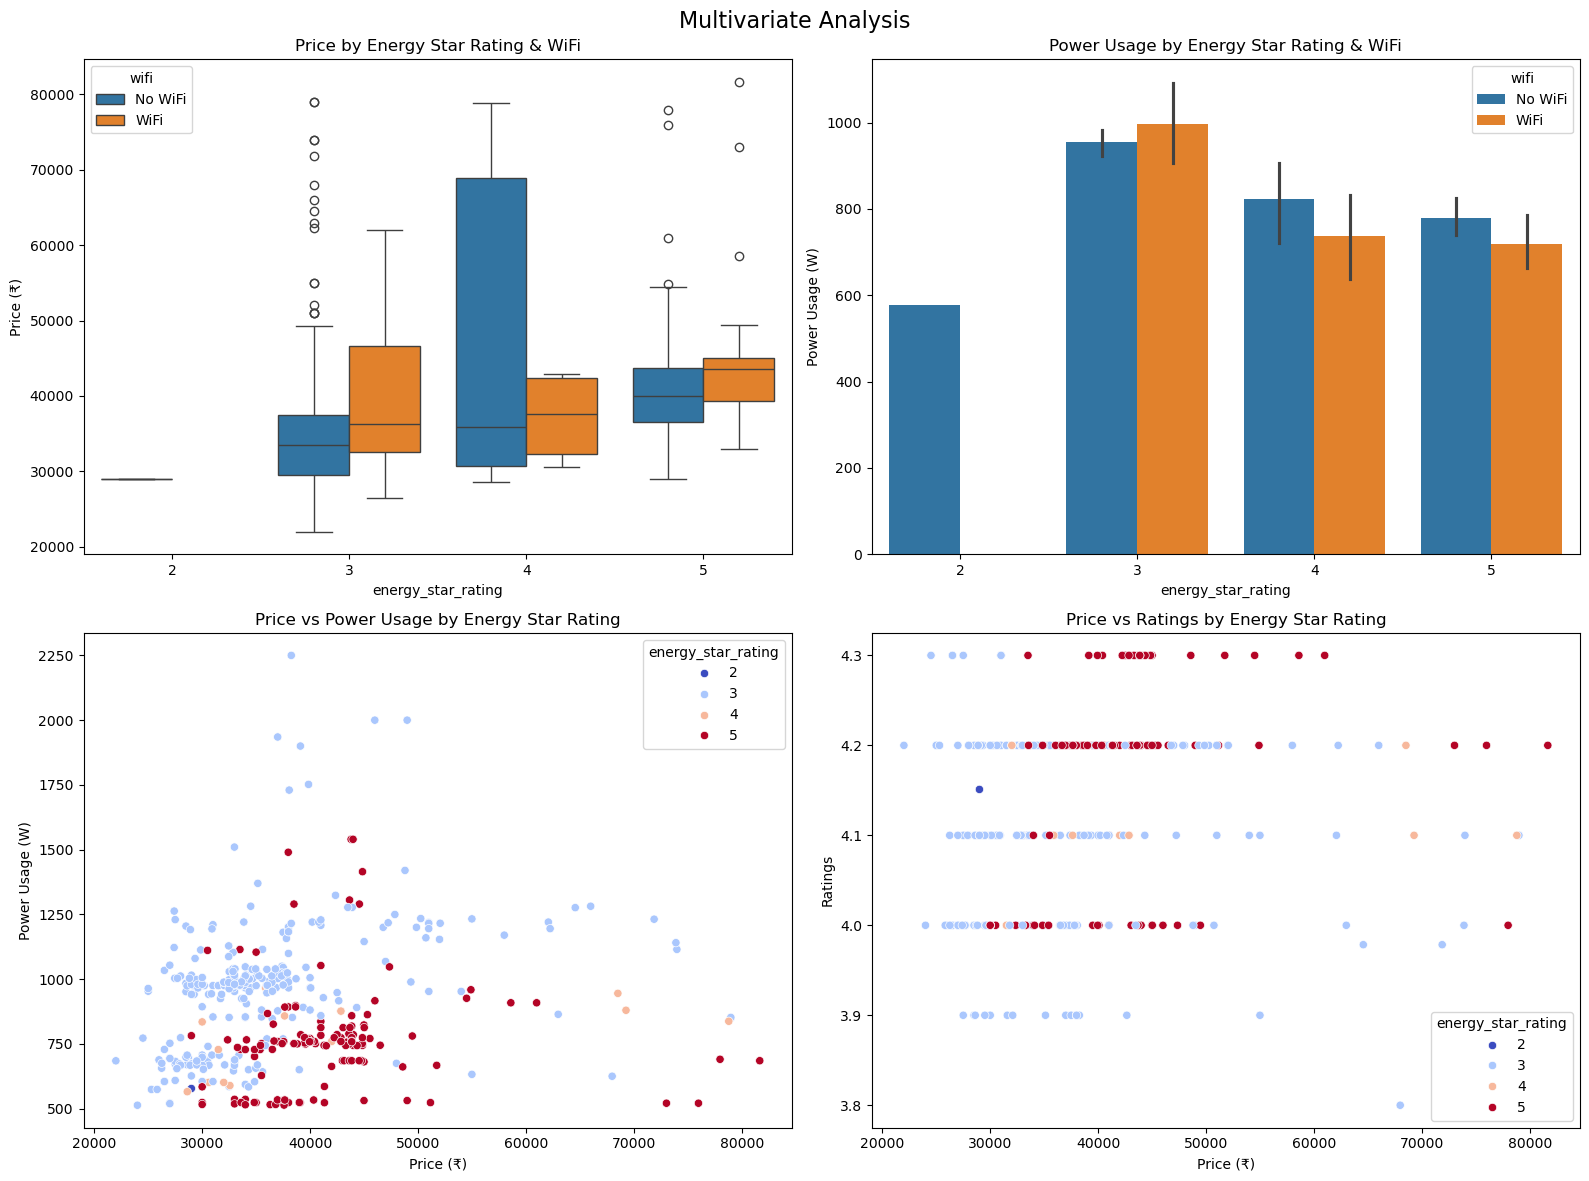

In [281]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Box plot — Price by Energy Star Rating hue WiFi
sns.boxplot(x='energy_star_rating', y='price', hue='wifi', data=df, ax=axes[0,0])
axes[0,0].set_title('Price by Energy Star Rating & WiFi')
axes[0,0].set_ylabel('Price (₹)')

# Power Usage by Energy Star Rating hue WiFi
sns.barplot(x='energy_star_rating', y='power_usage', hue='wifi', data=df, ax=axes[0,1])
axes[0,1].set_title('Power Usage by Energy Star Rating & WiFi')
axes[0,1].set_ylabel('Power Usage (W)')

# Scatter — Price vs Power Usage hue Energy Star Rating
sns.scatterplot(x='price', y='power_usage', hue='energy_star_rating', 
                palette='coolwarm', data=df, ax=axes[1,0])
axes[1,0].set_title('Price vs Power Usage by Energy Star Rating')
axes[1,0].set_xlabel('Price (₹)')
axes[1,0].set_ylabel('Power Usage (W)')

# Scatter — Price vs Ratings hue Energy Star Rating
sns.scatterplot(x='price', y='ratings', hue='energy_star_rating', 
                palette='coolwarm', data=df, ax=axes[1,1])
axes[1,1].set_title('Price vs Ratings by Energy Star Rating')
axes[1,1].set_xlabel('Price (₹)')
axes[1,1].set_ylabel('Ratings')

plt.suptitle('Multivariate Analysis', fontsize=16)
plt.tight_layout()
plt.show()

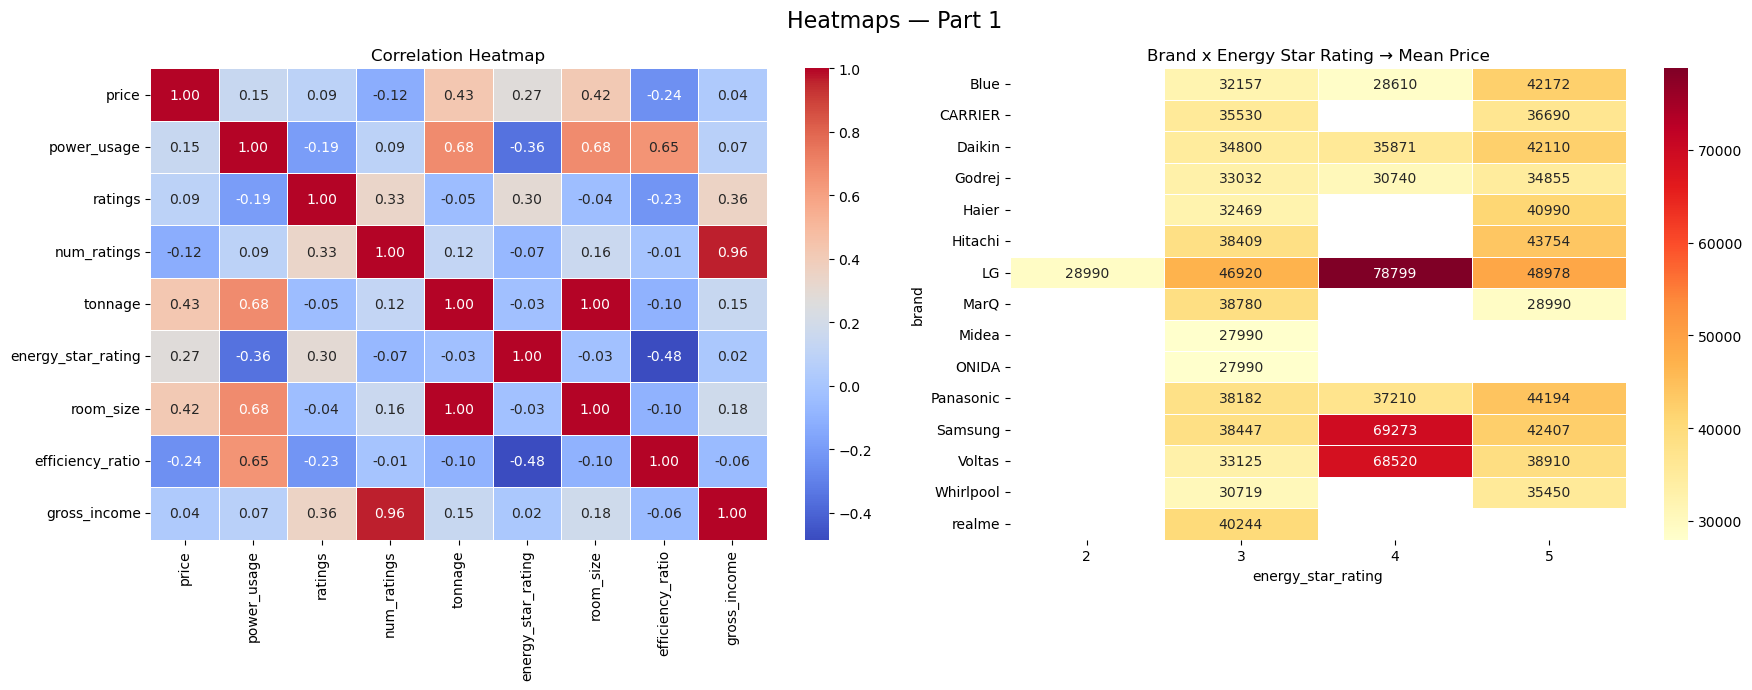

In [285]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Correlation Heatmap
corr = df[['price', 'power_usage', 'ratings', 'num_ratings', 
           'tonnage', 'energy_star_rating', 'room_size', 
           'efficiency_ratio', 'gross_income']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, ax=axes[0])
axes[0].set_title('Correlation Heatmap')

# Pivot Heatmap Brand x Energy Star → Mean Price
pivot1 = pd.pivot_table(df, values='price', index='brand', 
                         columns='energy_star_rating', aggfunc='mean')
sns.heatmap(pivot1, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5, ax=axes[1])
axes[1].set_title('Brand x Energy Star Rating → Mean Price')

plt.suptitle('Heatmaps — Part 1', fontsize=16)
plt.tight_layout()
plt.show()

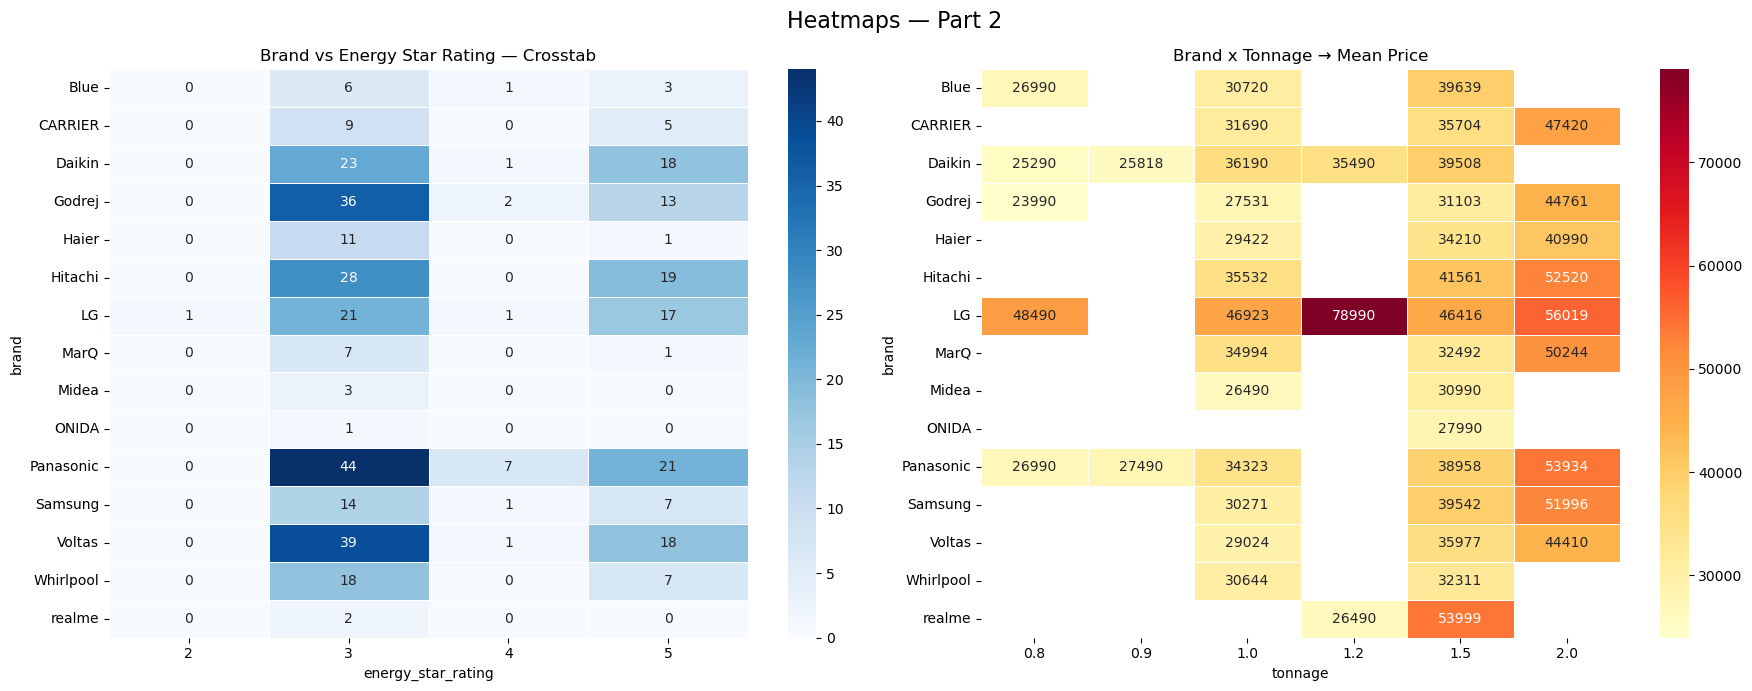

In [284]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Crosstab Brand vs Energy Star Rating
ct = pd.crosstab(df['brand'], df['energy_star_rating'])
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=axes[0])
axes[0].set_title('Brand vs Energy Star Rating — Crosstab')

# Pivot Heatmap Brand x Tonnage → Mean Price
pivot2 = pd.pivot_table(df, values='price', index='brand', 
                         columns='tonnage', aggfunc='mean')
sns.heatmap(pivot2, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5, ax=axes[1])
axes[1].set_title('Brand x Tonnage → Mean Price')

plt.suptitle('Heatmaps — Part 2', fontsize=16)
plt.tight_layout()
plt.show()